# Scalar Chebyshev2 vs Trapezoid: EuRoC Aggressive Windows

This notebook mirrors `scalar_quadrature_random_degree4_polynomials.ipynb`, but each scalar function is derived from the center 200 ms snippet of a merged EuRoC `gyro_norm` window. Each candidate 1-second window is still fit with Chebyshev2 (`N=50`, so `n=49`) to provide a stable reference function, but the selected candidate per dataset is the one whose middle interval `[0.4, 0.6]` has the highest local aggressive score. That avoids selecting a 1-second window only because something outside the interval of interest was aggressive. Set `USE_LAMBDA1_TIKHONOV = True` to add the Chebyshev2 derivative-matrix Tikhonov penalty to the noisy Chebyshev fits.


In [15]:
from pathlib import Path
import sys

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "python" / "imuFactors").exists():
    REPO_ROOT = Path("/Users/dellaert/git/imuFactors")
PYTHON_DIR = REPO_ROOT / "python"
if str(PYTHON_DIR) not in sys.path:
    sys.path.insert(0, str(PYTHON_DIR))

import imuFactors.euroc as euroc
import imuFactors.scalar_quadrature as scalar_quadrature
import imuFactors.spectral as spectral
import imuFactors.spectrogram as spectrogram

plt.rcParams.update({"figure.dpi": 120})


In [16]:
DATA_DIR = REPO_ROOT / "data" / "euroc"
DATA_FILES = euroc.discover_euroc_files(DATA_DIR)
if not DATA_FILES:
    raise FileNotFoundError(f"No EuRoC CSV files found in {DATA_DIR}")

CACHE_PATH = DATA_DIR / "euroc_aggressive_gyro_norm_cheb2_n50_windows.npz"
FORCE_REBUILD_CACHE = False

SIGNAL_COLUMN = "gyro_norm"
REFERENCE_BASIS = "chebyshev2"
REFERENCE_N = 50
REFERENCE_WINDOW_SECONDS = 1.0
REFERENCE_LAMBDA1 = 0.0
FULL_INTERVAL = (0.0, 1.0)
MIDDLE_INTERVAL = (0.4, 0.6)
SELECTION_INTERVAL = MIDDLE_INTERVAL
SELECTION_N = 10
CACHE_VERSION = 2

M_VALUES = [10, 20, 30, 40, 50]
N_VALUES = np.arange(2, 11)
NOISE_FRACTIONS = np.array([
    0.0, 0.025, 0.05, 0.06, 0.075, 0.10,
    0.12, 0.15, 0.17, 0.20, 0.225,
])
NUM_SEEDS = 100
RANDOM_SEED = 20260523
EVALUATION_COUNT = 151

LAMBDA1_SWEEP_M = 40
LAMBDA1_SWEEP_N = int(np.floor(np.sqrt(LAMBDA1_SWEEP_M)))
LAMBDA1_SWEEP_GRID = np.r_[0.0, np.logspace(-8, 1, 19)]

# Switch for Chebyshev2 Tikhonov regularization with derivative matrix D.
USE_LAMBDA1_TIKHONOV = True
LAMBDA1_TIKHONOV = 0.005
EXPERIMENT_LAMBDA1 = LAMBDA1_TIKHONOV if USE_LAMBDA1_TIKHONOV else 0.0

print(f"Found {len(DATA_FILES)} EuRoC CSV files in {DATA_DIR}")
print(f"cache: {CACHE_PATH}")
print(f"Chebyshev2 fit lambda1: {EXPERIMENT_LAMBDA1:g}")
print(f"selection interval: {SELECTION_INTERVAL}, selection N: {SELECTION_N}")


Found 11 EuRoC CSV files in /Users/dellaert/git/imuFactors/data/euroc
cache: /Users/dellaert/git/imuFactors/data/euroc/euroc_aggressive_gyro_norm_cheb2_n50_windows.npz
Chebyshev2 fit lambda1: 0.005
selection interval: (0.4, 0.6), selection N: 10


In [17]:
def _dataset_name(path: Path) -> str:
    return path.stem.removeprefix("euroc_")


def _cache_is_current(cache: dict) -> bool:
    required = {
        "cache_version",
        "selection_interval",
        "selection_N",
        "selection_activity",
        "selection_high_order_ratio",
        "selection_normalized_rmse",
        "snippet_start_seconds",
        "snippet_end_seconds",
        "window_activity",
        "window_high_order_ratio",
        "window_normalized_rmse",
    }
    if not required.issubset(cache):
        return False
    return (
        int(cache["cache_version"]) == CACHE_VERSION
        and int(cache["selection_N"]) == SELECTION_N
        and np.allclose(cache["selection_interval"], SELECTION_INTERVAL)
        and int(cache["reference_N"]) == REFERENCE_N
        and np.isclose(float(cache["reference_window_seconds"]), REFERENCE_WINDOW_SECONDS)
    )


def _selected_window_row(path: Path, result: spectrogram.SpectrogramFit) -> dict:
    diagnostics = spectrogram.interval_window_diagnostics(
        result,
        SELECTION_INTERVAL,
        N=SELECTION_N,
    )
    scores = np.asarray(diagnostics["aggressive_score"], dtype=float)
    window_index = int(np.nanargmax(scores))
    window_start_s = spectrogram.window_start_seconds(result, window_index)
    full_nrms = spectrogram.normalized_rmse(result)
    return {
        "dataset": _dataset_name(path),
        "csv_path": str(path),
        "window_index": window_index,
        "start_seconds": window_start_s,
        "snippet_start_seconds": window_start_s + SELECTION_INTERVAL[0],
        "snippet_end_seconds": window_start_s + SELECTION_INTERVAL[1],
        "aggressive_score": float(scores[window_index]),
        "selection_activity": float(diagnostics["activity"][window_index]),
        "selection_high_order_ratio": float(diagnostics["high_order_ratio"][window_index]),
        "selection_normalized_rmse": float(diagnostics["normalized_rmse"][window_index]),
        "window_activity": float(result.activity[window_index]),
        "window_high_order_ratio": float(result.high_order_ratio[window_index]),
        "window_normalized_rmse": float(full_nrms[window_index]),
        "raw_samples": result.samples[window_index, :, 0].astype(float),
        "cgl_node_values": result.coeffs[window_index, :, 0].astype(float),
        "sample_seconds": np.linspace(0.0, result.window_seconds, result.m),
    }


def build_aggressive_window_cache(data_files: list[Path], cache_path: Path) -> dict:
    rows = []
    for path in data_files:
        print(f"fitting {_dataset_name(path)}...")
        result = spectrogram.fit_spectral_windows(
            path,
            N=REFERENCE_N,
            basis=REFERENCE_BASIS,
            columns=[SIGNAL_COLUMN],
            window_seconds=REFERENCE_WINDOW_SECONDS,
            lambda1=REFERENCE_LAMBDA1,
        )
        rows.append(_selected_window_row(path, result))

    sample_seconds = rows[0]["sample_seconds"]
    if any(row["sample_seconds"].shape != sample_seconds.shape for row in rows):
        raise ValueError("Selected windows do not all have the same m")

    payload = {
        "cache_version": np.array(CACHE_VERSION, dtype=int),
        "datasets": np.array([row["dataset"] for row in rows]),
        "csv_paths": np.array([row["csv_path"] for row in rows]),
        "window_indices": np.array([row["window_index"] for row in rows], dtype=int),
        "start_seconds": np.array([row["start_seconds"] for row in rows], dtype=float),
        "snippet_start_seconds": np.array([row["snippet_start_seconds"] for row in rows], dtype=float),
        "snippet_end_seconds": np.array([row["snippet_end_seconds"] for row in rows], dtype=float),
        "aggressive_scores": np.array([row["aggressive_score"] for row in rows], dtype=float),
        "selection_activity": np.array([row["selection_activity"] for row in rows], dtype=float),
        "selection_high_order_ratio": np.array([row["selection_high_order_ratio"] for row in rows], dtype=float),
        "selection_normalized_rmse": np.array([row["selection_normalized_rmse"] for row in rows], dtype=float),
        "window_activity": np.array([row["window_activity"] for row in rows], dtype=float),
        "window_high_order_ratio": np.array([row["window_high_order_ratio"] for row in rows], dtype=float),
        "window_normalized_rmse": np.array([row["window_normalized_rmse"] for row in rows], dtype=float),
        "raw_samples": np.stack([row["raw_samples"] for row in rows]),
        "cgl_node_values": np.stack([row["cgl_node_values"] for row in rows]),
        "sample_seconds": sample_seconds,
        "cgl_node_seconds": spectral.chebyshev2_points(REFERENCE_N, FULL_INTERVAL),
        "reference_N": np.array(REFERENCE_N, dtype=int),
        "reference_window_seconds": np.array(REFERENCE_WINDOW_SECONDS, dtype=float),
        "middle_interval": np.array(MIDDLE_INTERVAL, dtype=float),
        "selection_interval": np.array(SELECTION_INTERVAL, dtype=float),
        "selection_N": np.array(SELECTION_N, dtype=int),
    }
    # Backward-readable aliases now refer to the local center-snippet diagnostics.
    payload["activity"] = payload["selection_activity"]
    payload["high_order_ratio"] = payload["selection_high_order_ratio"]
    payload["normalized_rmse"] = payload["selection_normalized_rmse"]
    np.savez_compressed(cache_path, **payload)
    return payload


def load_aggressive_window_cache(cache_path: Path) -> dict:
    with np.load(cache_path, allow_pickle=False) as archive:
        return {key: archive[key] for key in archive.files}


In [18]:
if FORCE_REBUILD_CACHE or not CACHE_PATH.exists():
    cache = build_aggressive_window_cache(DATA_FILES, CACHE_PATH)
else:
    cache = load_aggressive_window_cache(CACHE_PATH)
    if not _cache_is_current(cache):
        print("cache is stale for center-200ms selection; rebuilding...")
        cache = build_aggressive_window_cache(DATA_FILES, CACHE_PATH)

metadata = pd.DataFrame(
    {
        "dataset": cache["datasets"],
        "window_index": cache["window_indices"],
        "window_start_s": cache["start_seconds"],
        "snippet_start_s": cache["snippet_start_seconds"],
        "snippet_end_s": cache["snippet_end_seconds"],
        "center_200ms_score": cache["aggressive_scores"],
        "center_activity": cache["selection_activity"],
        "center_high_order_ratio": cache["selection_high_order_ratio"],
        "center_normalized_rmse": cache["selection_normalized_rmse"],
        "full_window_activity": cache["window_activity"],
        "full_window_high_order_ratio": cache["window_high_order_ratio"],
        "full_window_normalized_rmse": cache["window_normalized_rmse"],
    }
).sort_values("center_200ms_score", ascending=False)
metadata


,dataset,window_index,window_start_s,snippet_start_s,snippet_end_s,center_200ms_score,center_activity,center_high_order_ratio,center_normalized_rmse,full_window_activity,full_window_high_order_ratio,full_window_normalized_rmse
5,V101,23,23.0,23.4,23.6,13.866086,1.620595,0.887578,0.139073,1.103117,0.619549,0.122220
7,V103,68,68.0,68.4,68.6,9.266305,0.877133,0.858795,0.111677,0.846550,0.591947,0.141855
6,V102,69,69.0,69.4,69.6,8.142701,0.928953,0.750667,0.075322,0.660955,0.482588,0.076724
1,MH02,53,53.0,53.4,53.6,7.924182,1.200057,0.836079,0.295372,1.668064,0.762921,0.315449
2,MH03,45,45.0,45.4,45.6,7.781581,0.983607,0.785667,0.181654,0.768929,0.582832,0.185725
3,MH04,49,49.0,49.4,49.6,6.887917,1.038007,0.759591,0.243285,0.879827,0.608021,0.243058
9,V202,54,54.0,54.4,54.6,6.554681,0.905636,0.724456,0.069618,1.099300,0.464610,0.086714
8,V201,85,85.0,85.4,85.6,6.464583,0.783263,0.761189,0.188188,1.045416,0.774878,0.202649
0,MH01,38,38.0,38.4,38.6,6.372596,1.016883,0.788480,0.334360,0.734005,0.561920,0.288262
4,MH05,16,16.0,16.4,16.6,6.302090,0.910404,0.798610,0.262509,0.709193,0.675921,0.258339


In [19]:
FUNCTIONS = [
    scalar_quadrature.scalar_function_from_chebyshev2_nodes(
        f"{dataset} center-200ms aggressive gyro_norm", cgl_node_values, FULL_INTERVAL
    )
    for dataset, cgl_node_values in zip(cache["datasets"], cache["cgl_node_values"])
]

pd.DataFrame(
    cache["cgl_node_values"],
    columns=[f"cgl{k}" for k in range(int(cache["reference_N"]))],
    index=[function.name for function in FUNCTIONS],
).iloc[:, :10]


,cgl0,cgl1,cgl2,cgl3,cgl4,cgl5,cgl6,cgl7,cgl8,cgl9
MH01 center-200ms aggressive gyro_norm,0.290513,-0.088271,0.235017,0.315149,0.270745,0.240696,0.297421,0.229145,0.218205,0.217325
MH02 center-200ms aggressive gyro_norm,0.188206,-0.140189,0.049227,0.222951,0.161690,0.186309,0.197911,0.212536,0.285031,0.227705
MH03 center-200ms aggressive gyro_norm,0.399878,0.298935,0.431465,0.404418,0.442879,0.409937,0.401926,0.306691,0.326010,0.321295
MH04 center-200ms aggressive gyro_norm,0.090533,0.118544,0.108527,0.110613,0.092417,0.091272,0.132912,0.136598,0.123749,0.085385
MH05 center-200ms aggressive gyro_norm,0.062105,-0.024593,0.052585,0.040489,0.054198,0.046315,0.089446,0.084675,0.140806,0.092220
V101 center-200ms aggressive gyro_norm,0.426749,0.724276,0.498059,0.387931,0.444307,0.482044,0.411185,0.427552,0.363119,0.341416
V102 center-200ms aggressive gyro_norm,1.158269,1.211563,1.225316,1.185506,1.205263,1.211548,1.216466,1.234751,1.169389,1.077592
V103 center-200ms aggressive gyro_norm,1.301137,1.665263,1.465982,1.273495,1.333328,1.272243,1.228098,1.117854,1.061617,0.943065
V201 center-200ms aggressive gyro_norm,0.207278,0.089798,0.238903,0.208763,0.181727,0.108017,0.127870,0.092775,0.174495,0.094842
V202 center-200ms aggressive gyro_norm,1.322526,1.128901,1.236490,1.328507,1.386529,1.420123,1.439705,1.385671,1.363185,1.339633


In [20]:
def plot_cached_window_previews(cache: dict) -> go.Figure:
    datasets = list(cache["datasets"])
    rows = len(datasets)
    fig = make_subplots(
        rows=rows,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.012,
        subplot_titles=datasets,
    )
    dense_seconds = np.linspace(0.0, 1.0, 401)
    for row, (dataset, cgl_node_values, raw_samples) in enumerate(
        zip(cache["datasets"], cache["cgl_node_values"], cache["raw_samples"]), start=1
    ):
        function = scalar_quadrature.scalar_function_from_chebyshev2_nodes(
            str(dataset), cgl_node_values, FULL_INTERVAL
        )
        fig.add_trace(
            go.Scatter(
                x=cache["sample_seconds"],
                y=raw_samples,
                mode="markers",
                marker=dict(size=3),
                name=f"{dataset} samples",
                showlegend=False,
            ),
            row=row,
            col=1,
        )
        fig.add_trace(
            go.Scatter(
                x=dense_seconds,
                y=function.value(dense_seconds),
                mode="lines",
                line=dict(width=2),
                name=f"{dataset} Chebyshev2 fit",
                showlegend=False,
            ),
            row=row,
            col=1,
        )
        fig.add_vrect(
            x0=MIDDLE_INTERVAL[0],
            x1=MIDDLE_INTERVAL[1],
            fillcolor="rgba(80, 140, 255, 0.16)",
            line_width=0,
            row=row,
            col=1,
        )
        fig.update_yaxes(title_text="gyro", row=row, col=1)
    fig.update_xaxes(title_text="seconds inside selected 1 s reference window", row=rows, col=1)
    fig.update_layout(
        title="Selected 1-second reference windows ranked by their center 200 ms snippets",
        height=max(700, 145 * rows),
        margin=dict(l=70, r=30, t=80, b=55),
    )
    return fig

plot_cached_window_previews(cache).show()


In [21]:
N_values_by_m = {
    m: N_VALUES
    for m in M_VALUES
}
pd.DataFrame(
    {
        "m": list(N_values_by_m),
        "N_min": [values[0] for values in N_values_by_m.values()],
        "N_max": [values[-1] for values in N_values_by_m.values()],
        "sqrt_m": [np.sqrt(m) for m in N_values_by_m],
        "num_N": [len(values) for values in N_values_by_m.values()],
    }
)


,m,N_min,N_max,sqrt_m,num_N
0,10,2,10,3.162278,9
1,20,2,10,4.472136,9
2,30,2,10,5.477226,9
3,40,2,10,6.324555,9
4,50,2,10,7.071068,9


In [22]:
runs = []
for m, N_grid in N_values_by_m.items():
    runs.append(
        scalar_quadrature.run_scalar_monte_carlo(
            FUNCTIONS,
            m_values=[m],
            N_values=N_grid,
            noise_fractions=NOISE_FRACTIONS,
            num_seeds=NUM_SEEDS,
            seed=RANDOM_SEED,
            interval=MIDDLE_INTERVAL,
            evaluation_count=EVALUATION_COUNT,
            lambda1=EXPERIMENT_LAMBDA1,
        )
    )

method_metrics = pd.concat(
    [run.method_metrics for run in runs], ignore_index=True
)
comparisons = pd.concat(
    [run.comparisons for run in runs], ignore_index=True
)
display(pd.DataFrame({"quantity": ["lambda1 Tikhonov D penalty"], "value": [EXPERIMENT_LAMBDA1]}))
comparisons.head()


,quantity,value
0,lambda1 Tikhonov D penalty,0.005


,function,noise_fraction,noise_std,m,N,n,lambda1,end_error,rmse_error,max_error
0,MH01 center-200ms aggressive gyro_norm,0.0,0.0,10,2,1,0.005,0.000173,0.001187,0.002558
1,MH01 center-200ms aggressive gyro_norm,0.0,0.0,10,3,2,0.005,0.000064,0.001074,0.002263
2,MH01 center-200ms aggressive gyro_norm,0.0,0.0,10,4,3,0.005,0.000064,0.000424,0.000715
3,MH01 center-200ms aggressive gyro_norm,0.0,0.0,10,5,4,0.005,0.000197,0.000325,0.000694
4,MH01 center-200ms aggressive gyro_norm,0.0,0.0,10,6,5,0.005,0.000166,0.000287,0.000801


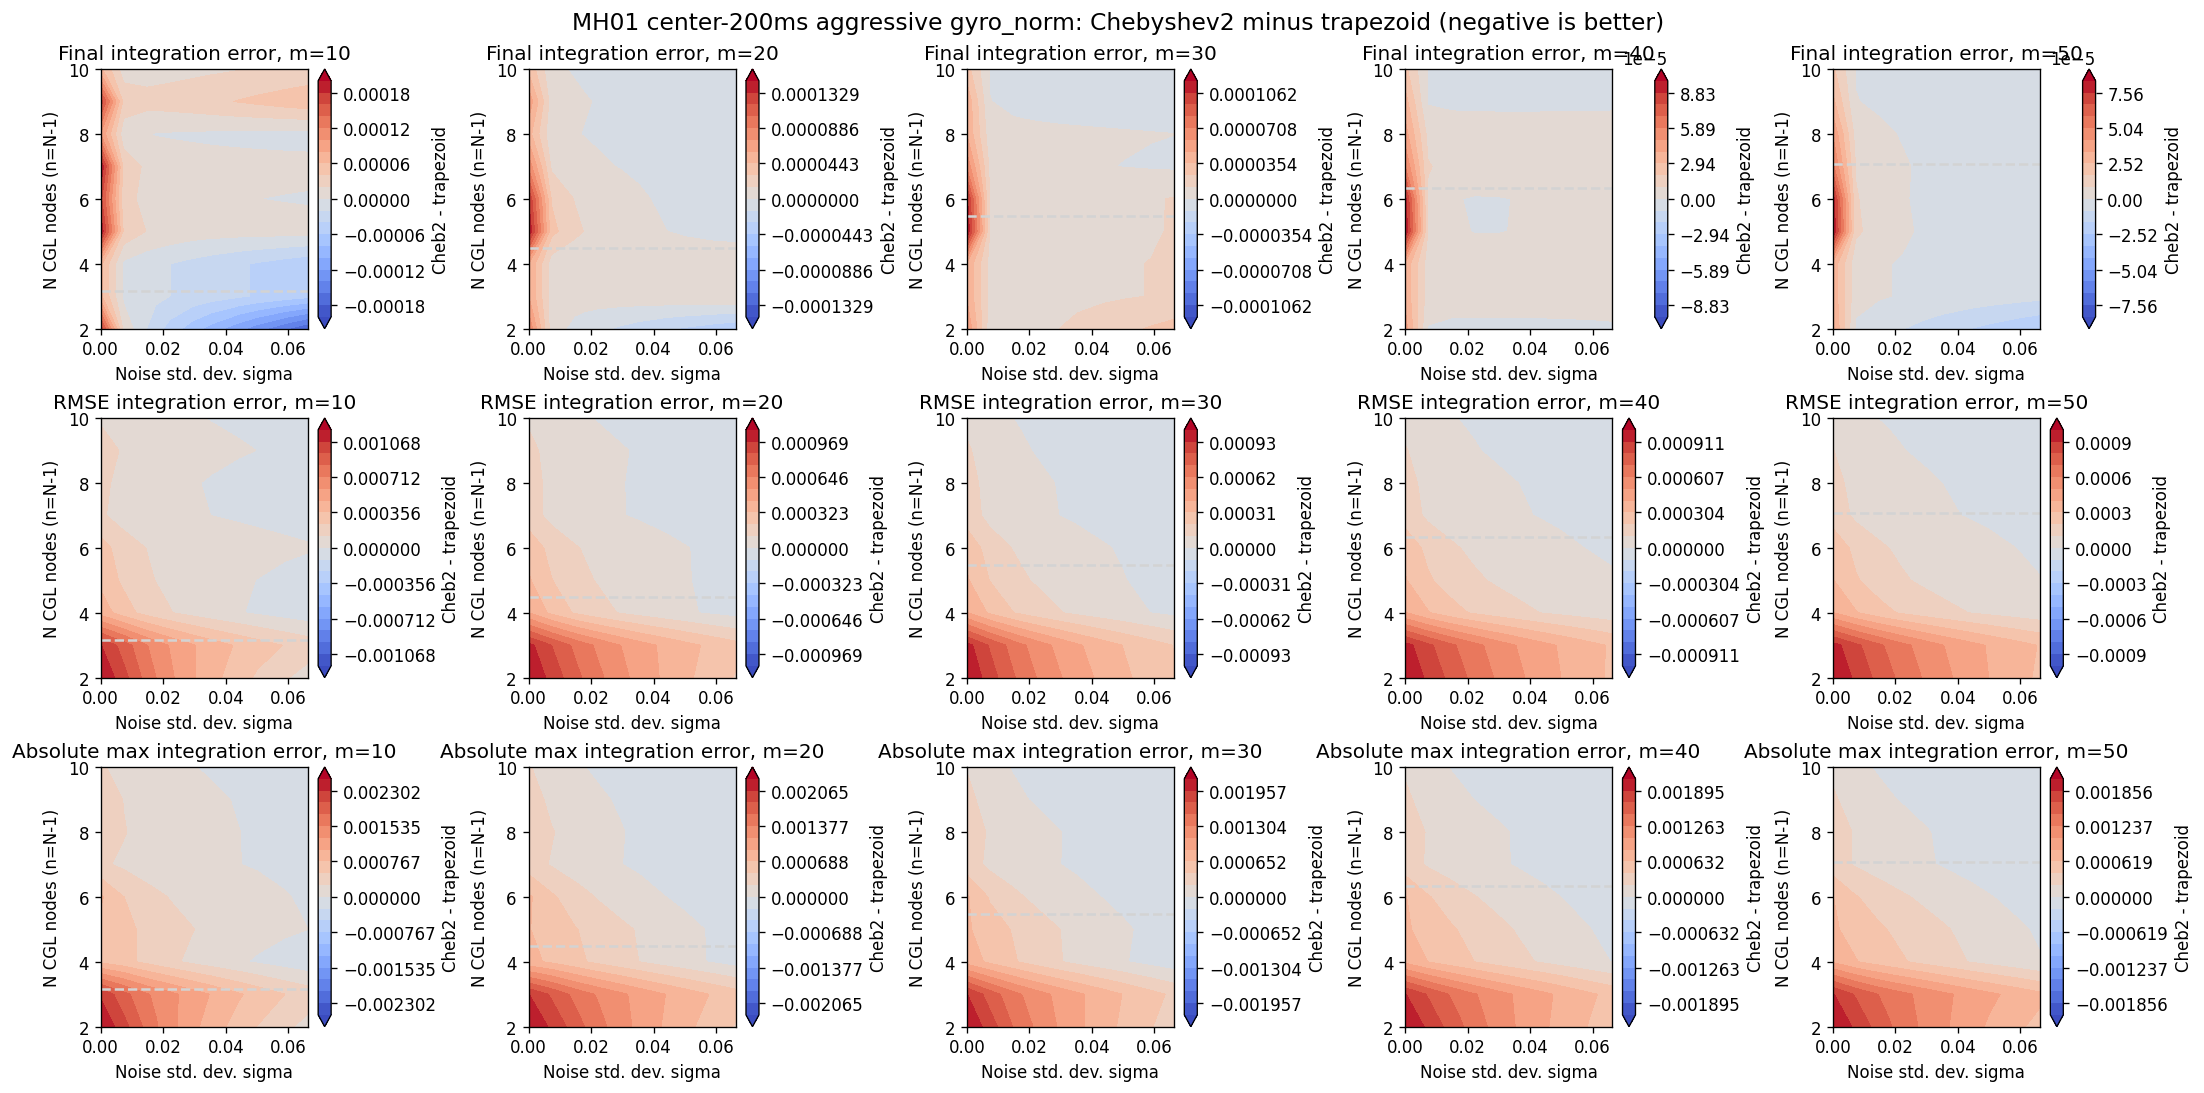

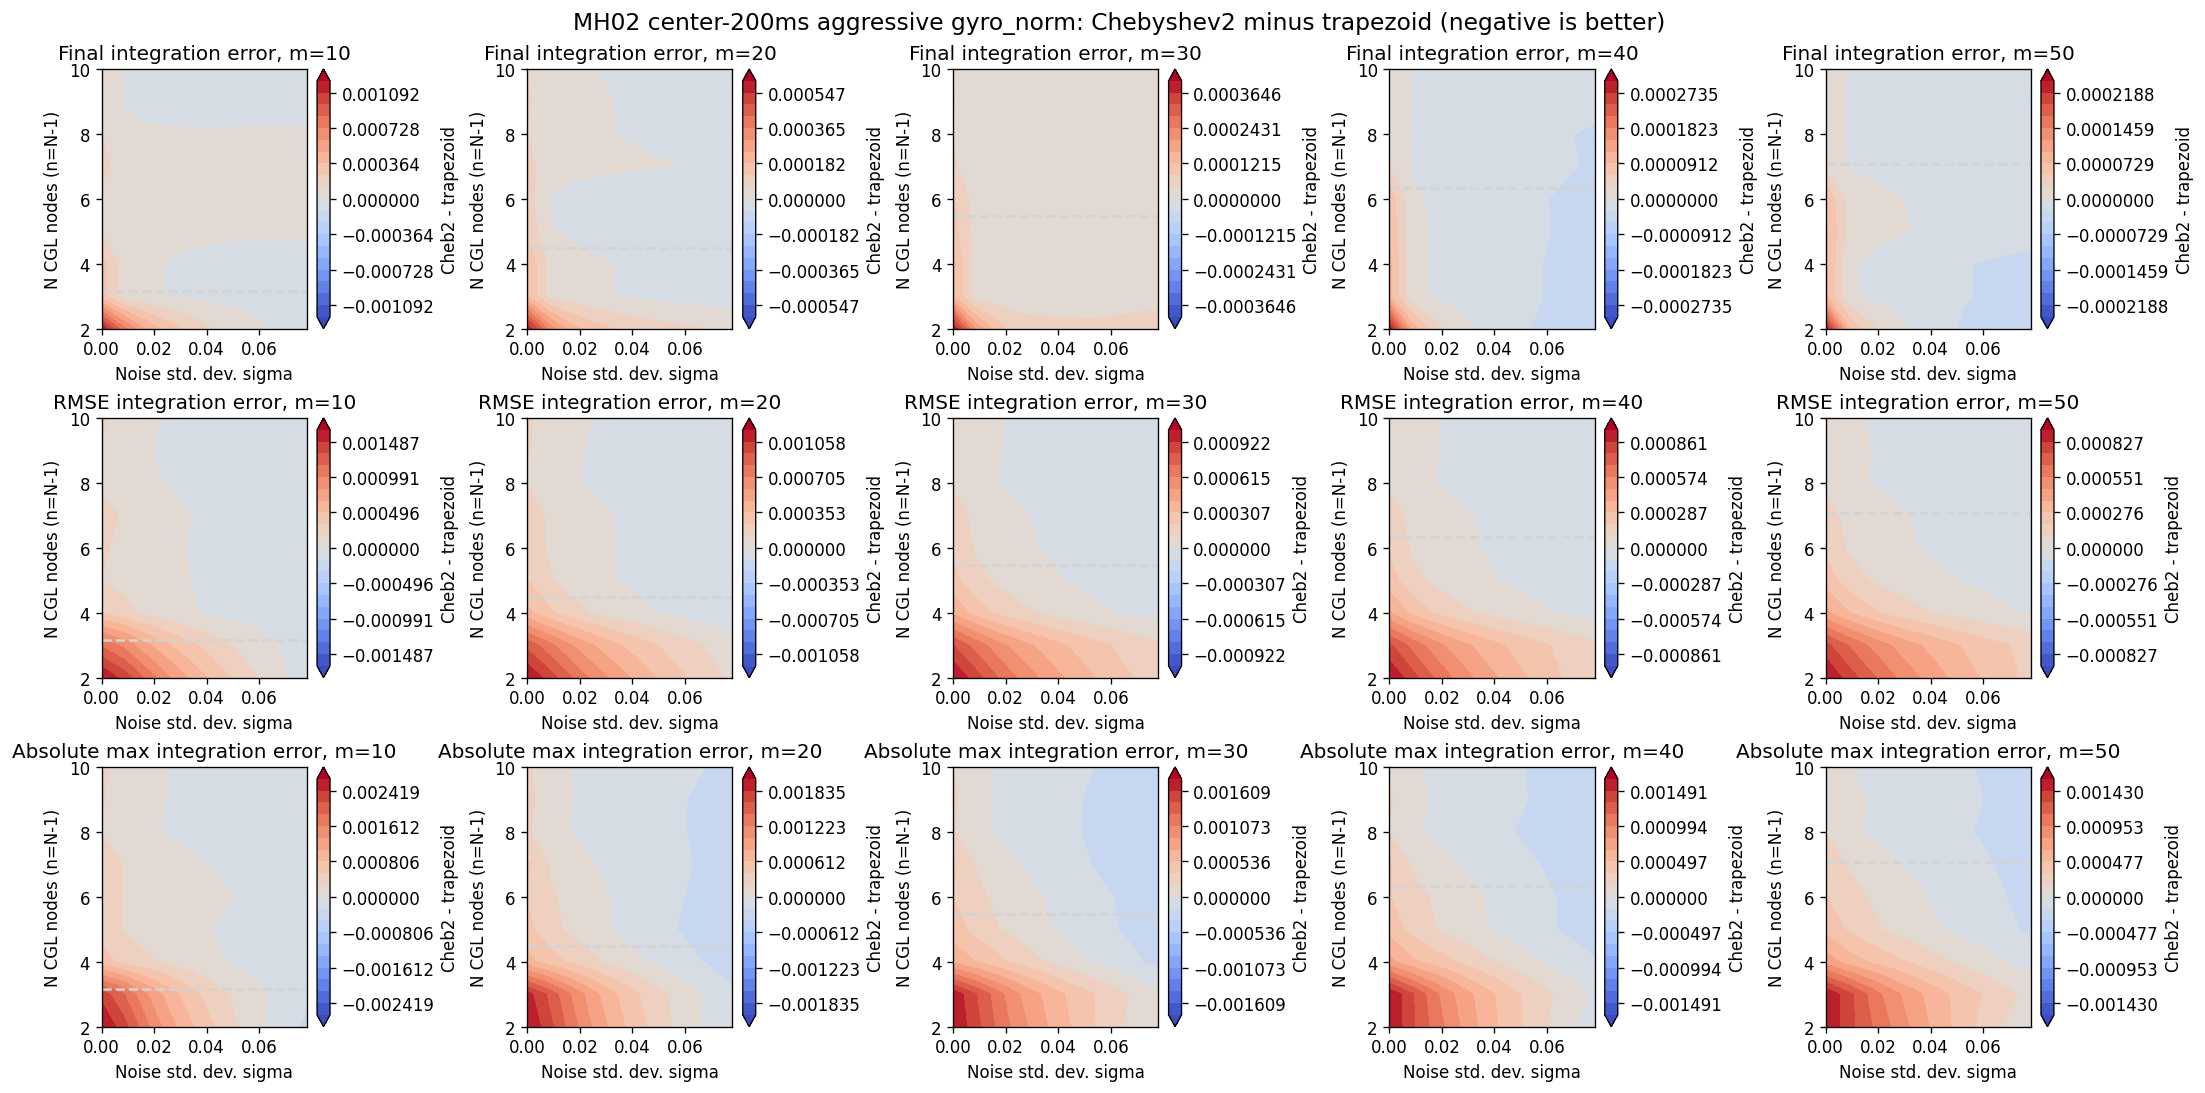

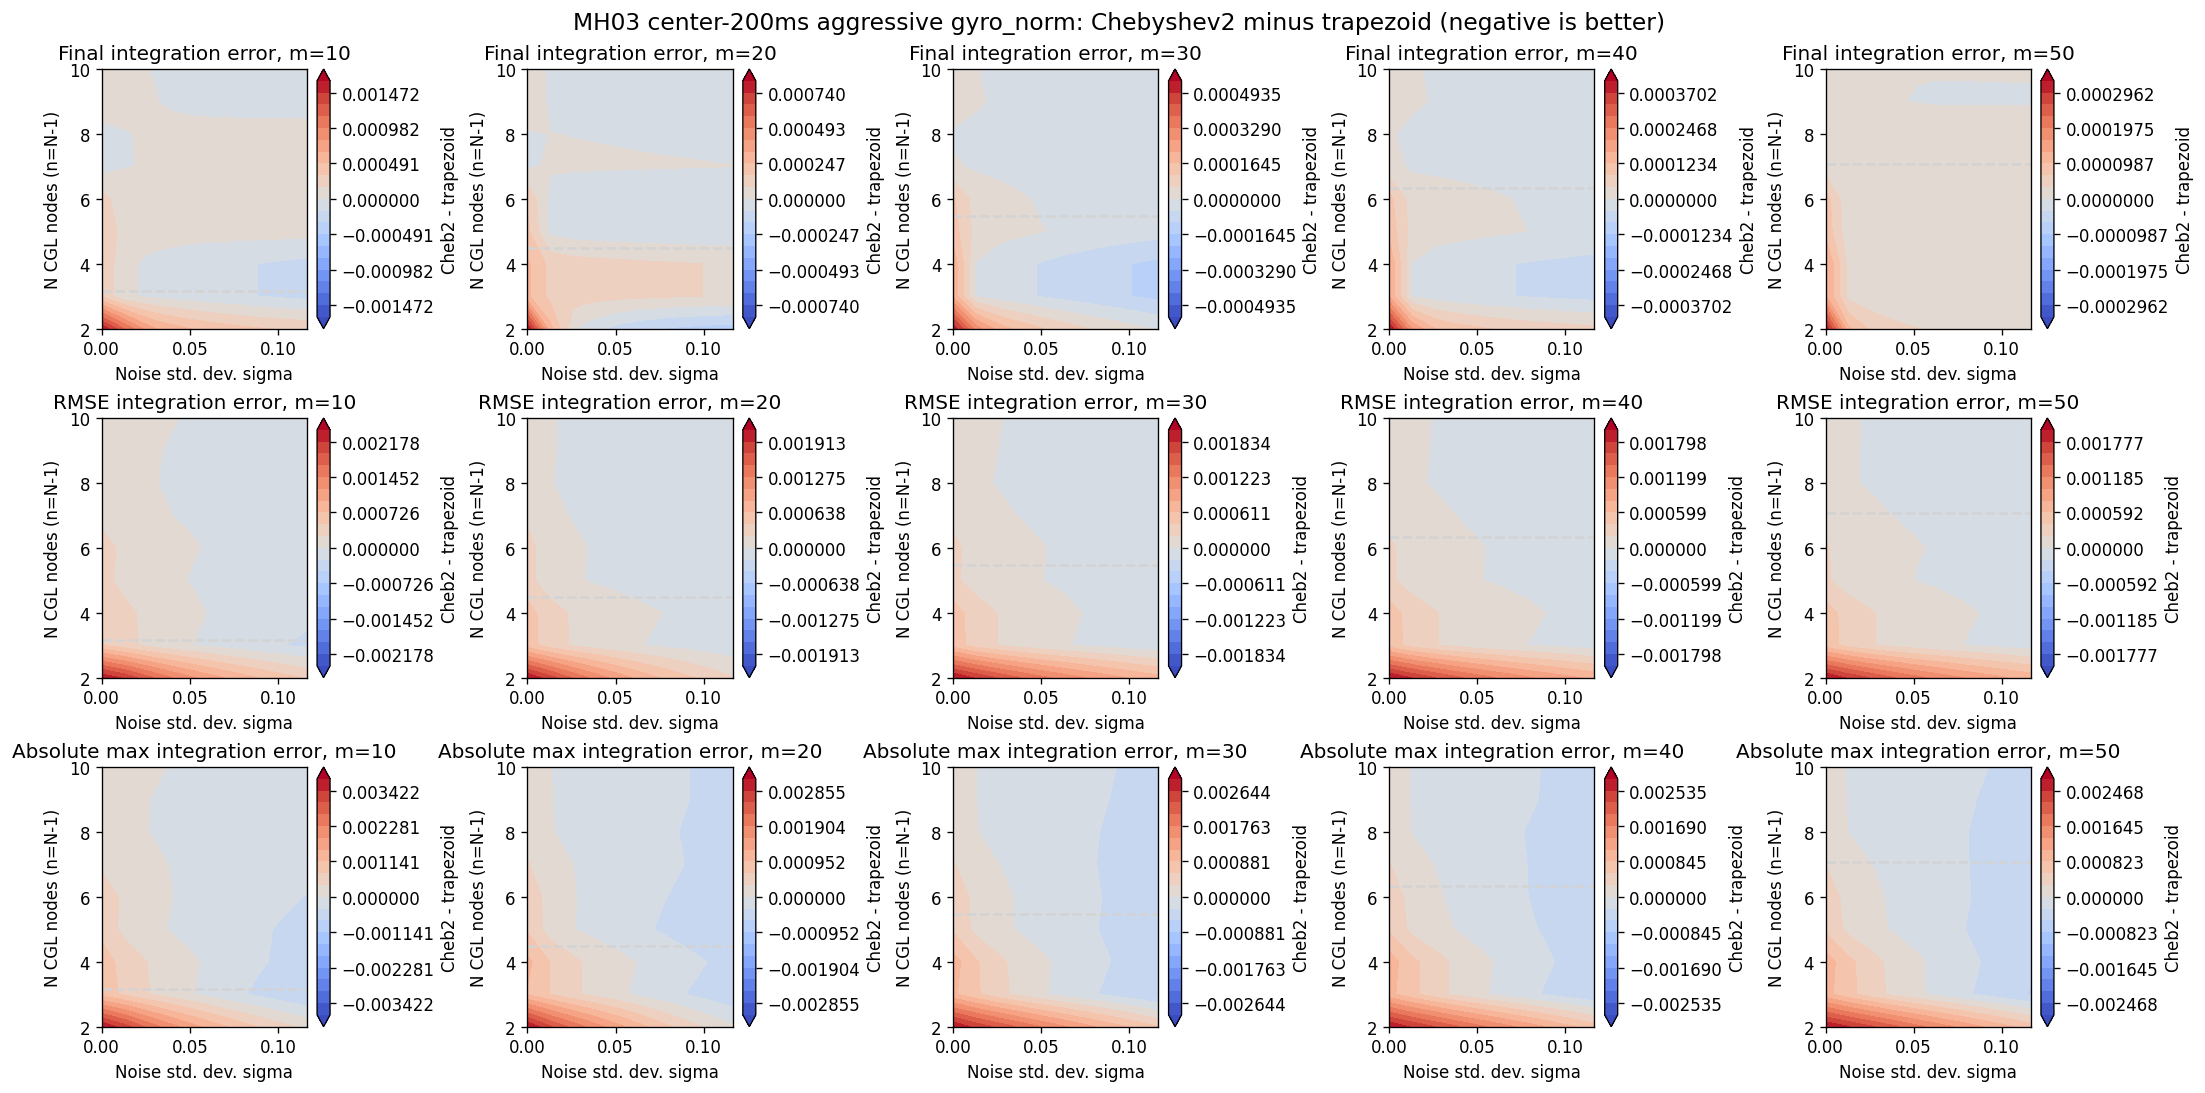

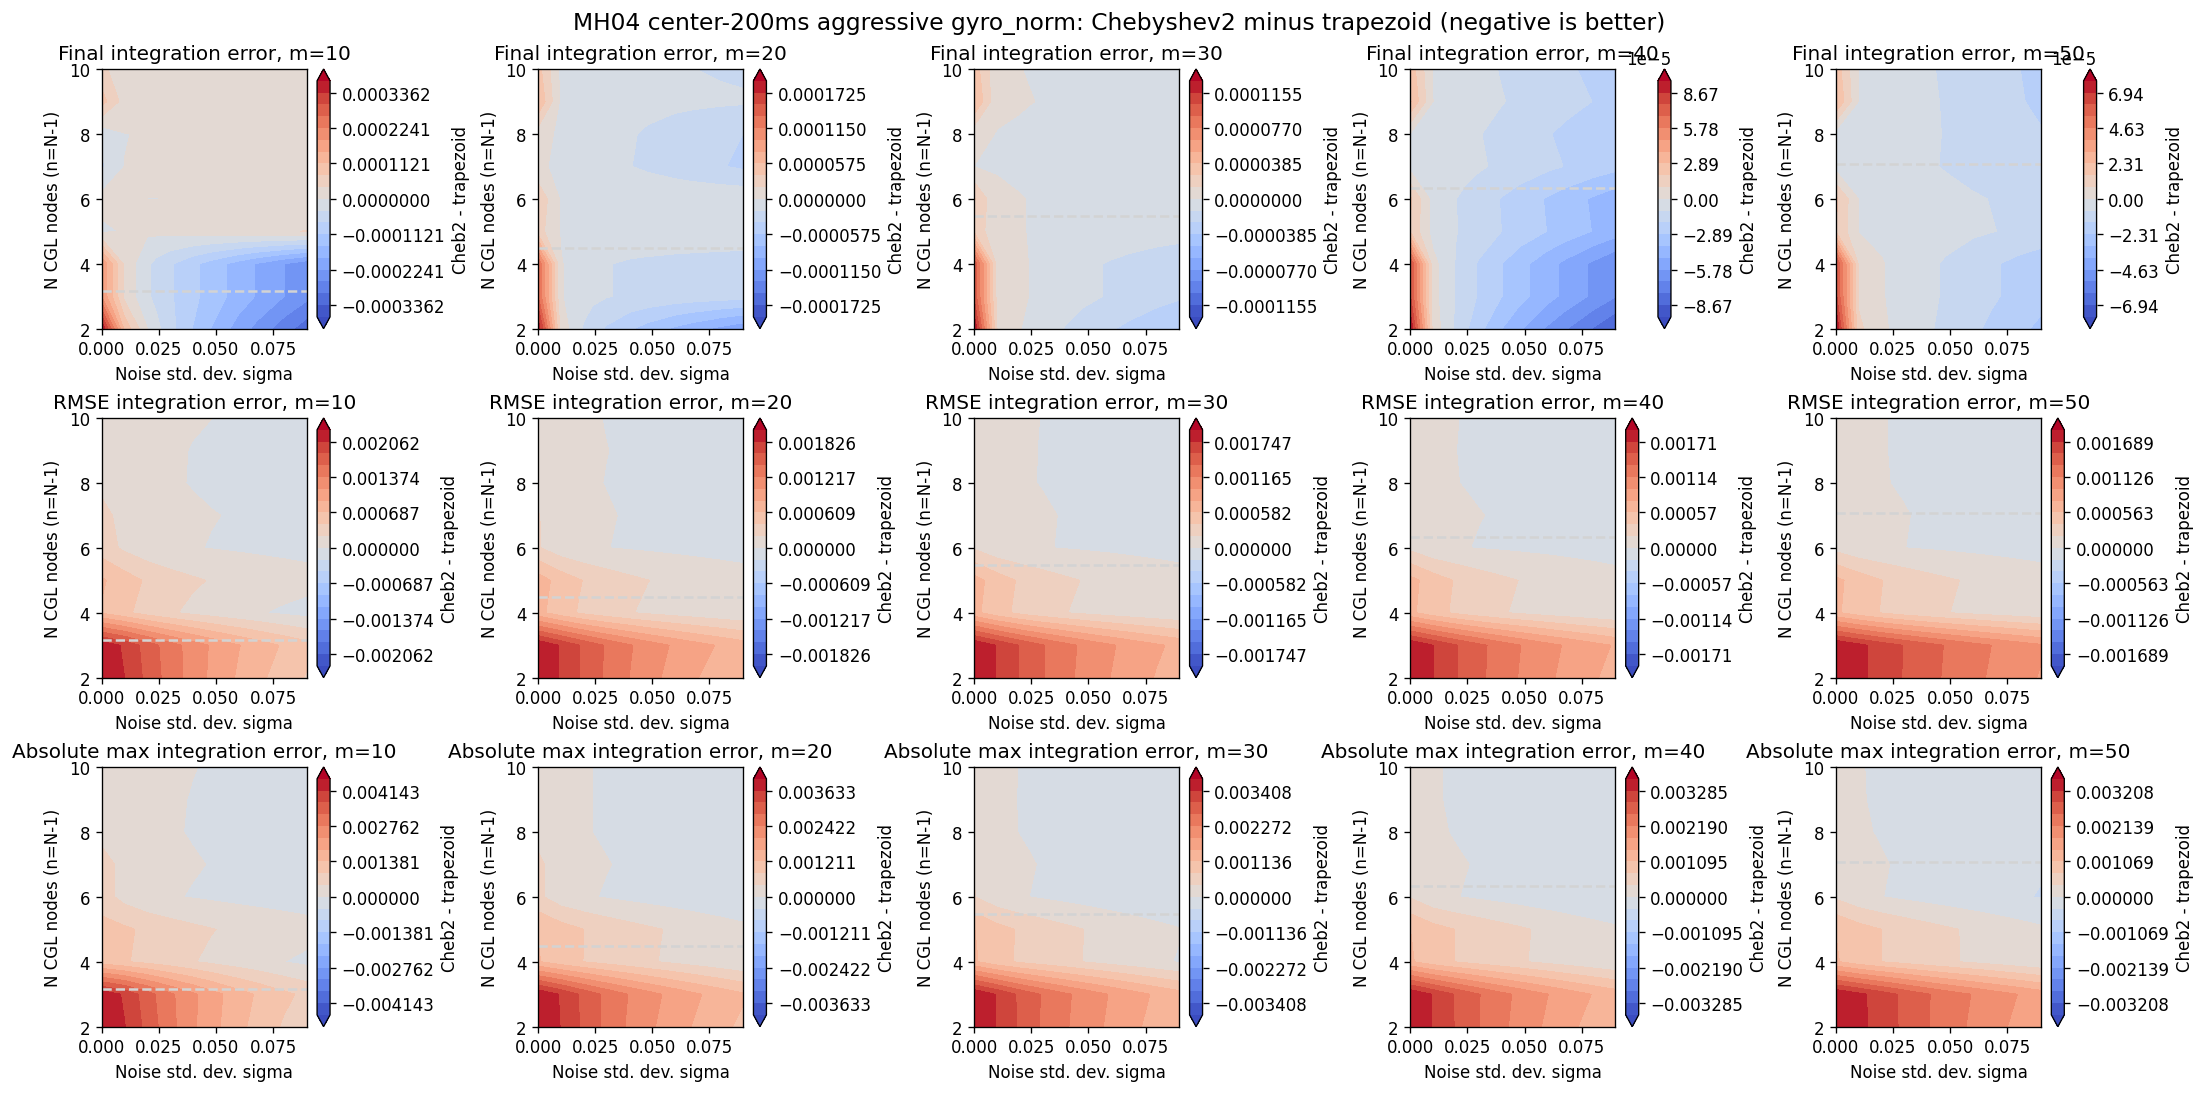

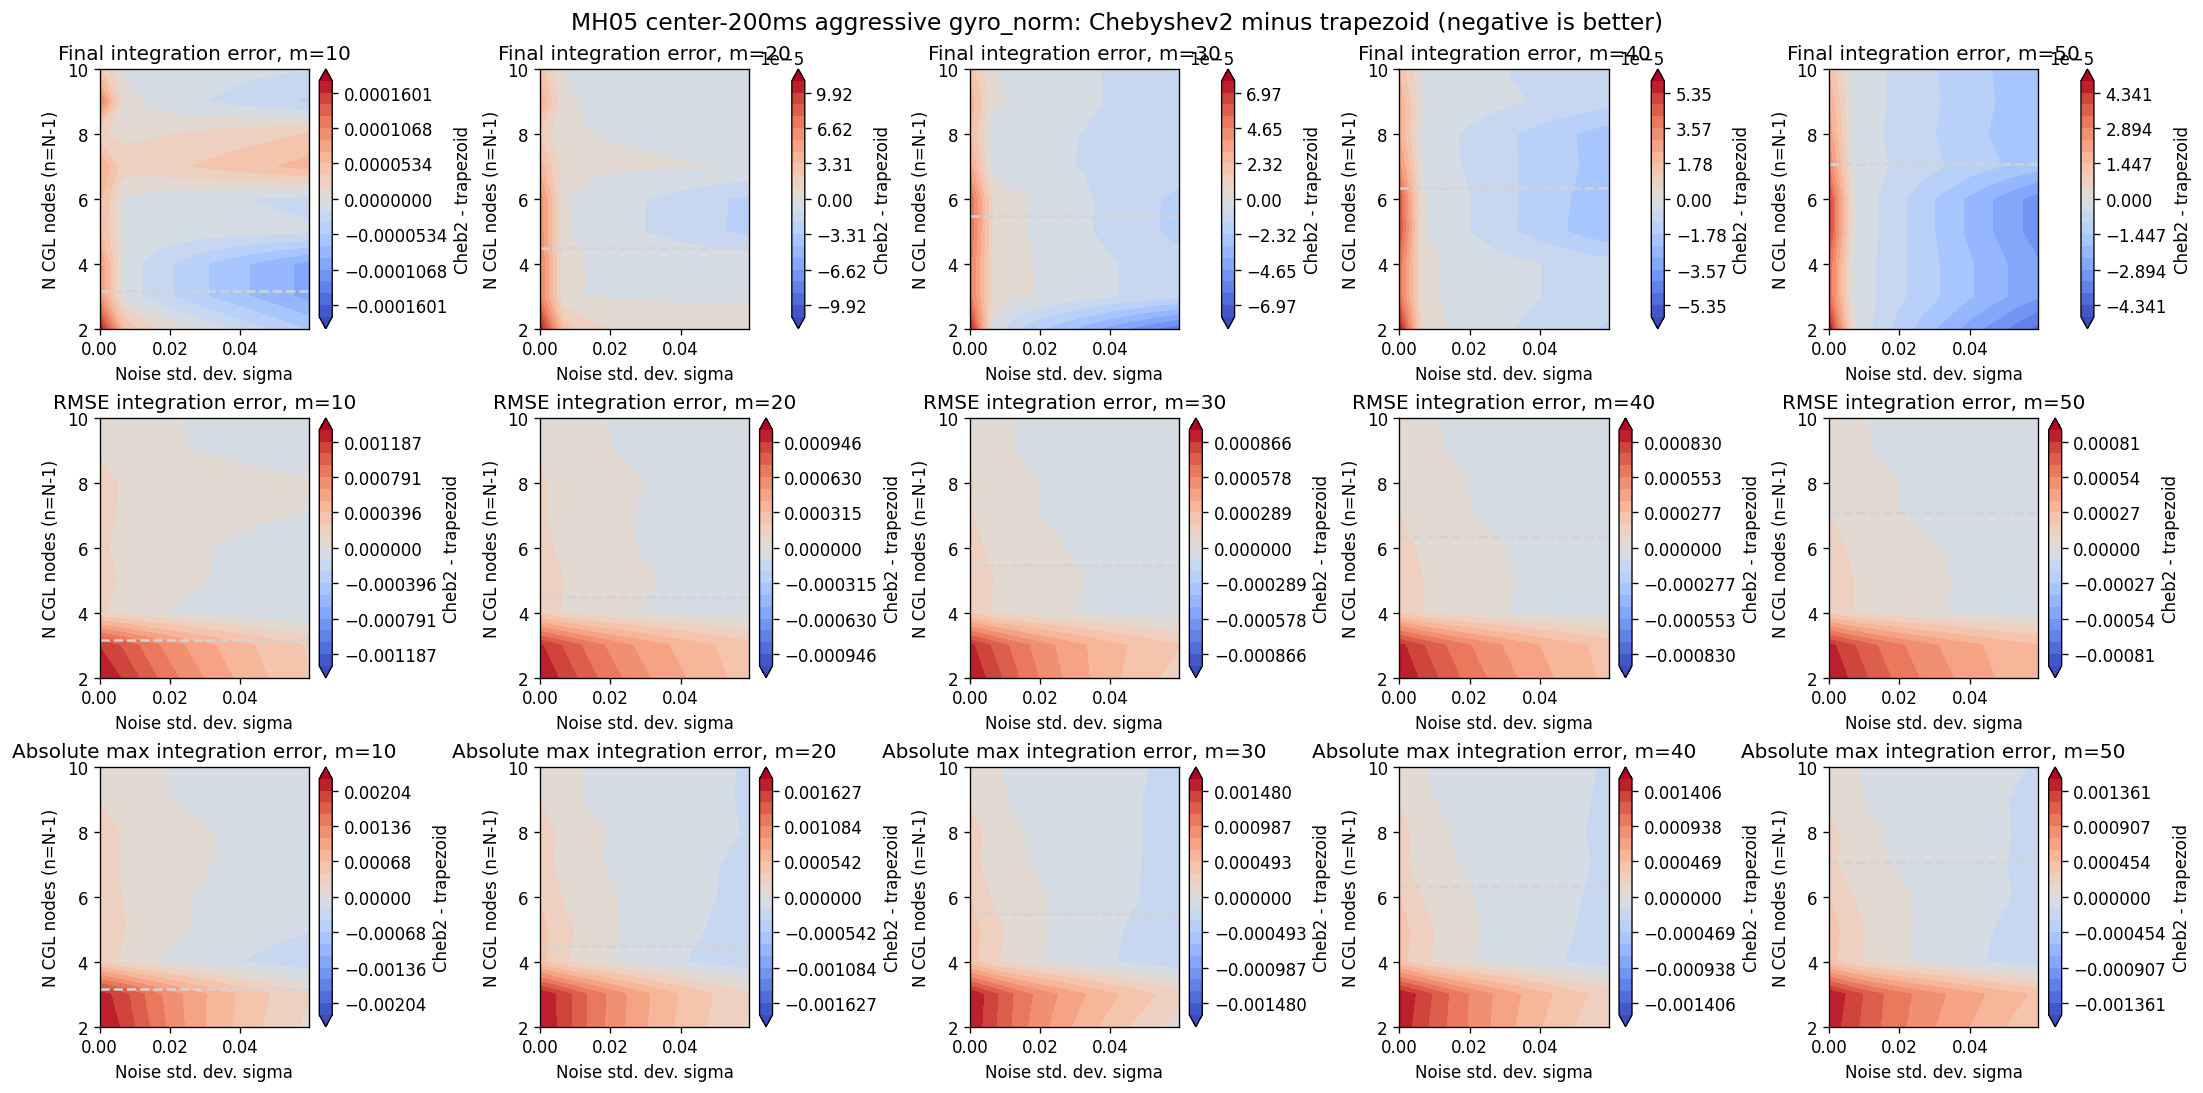

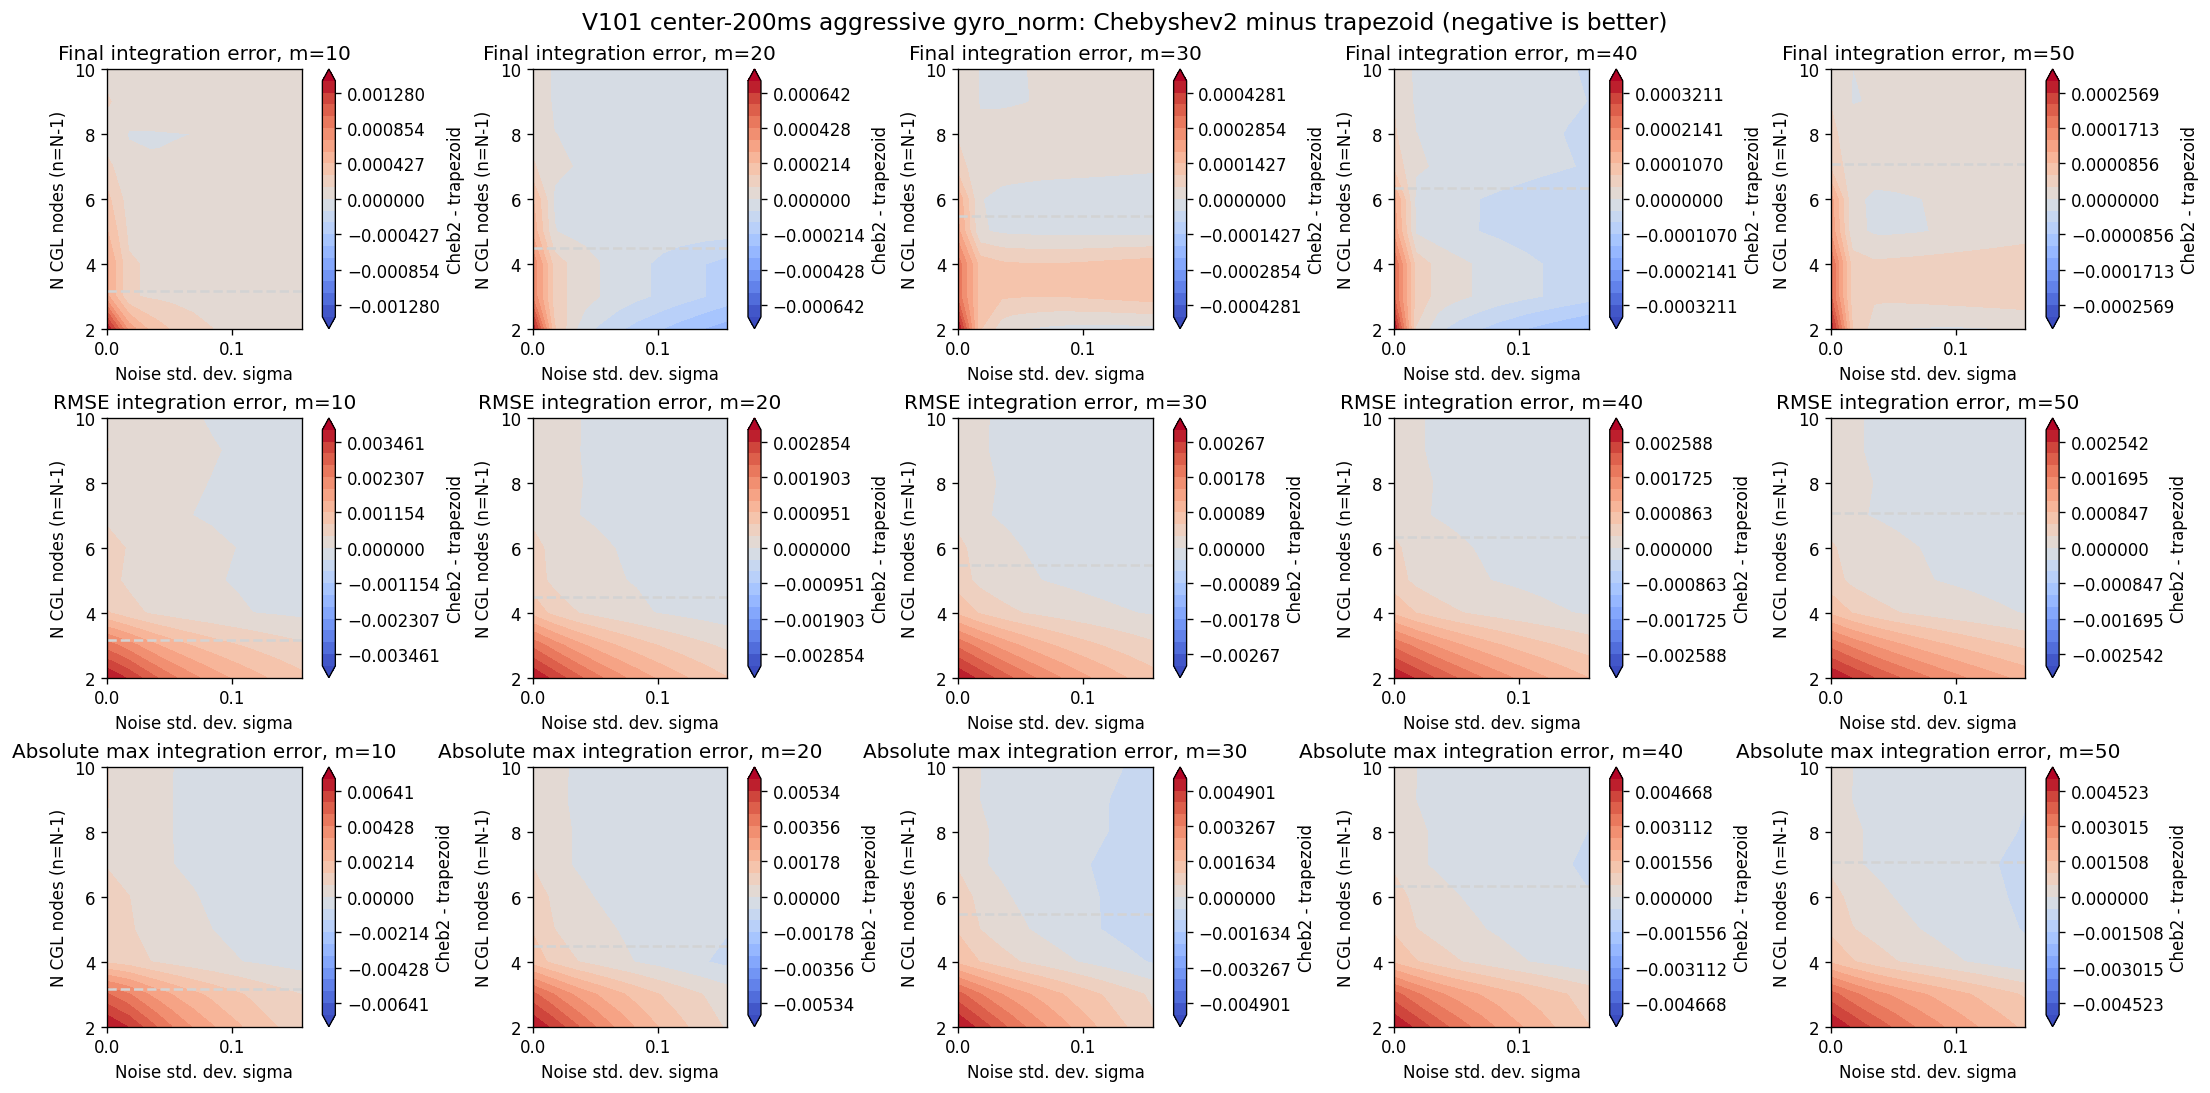

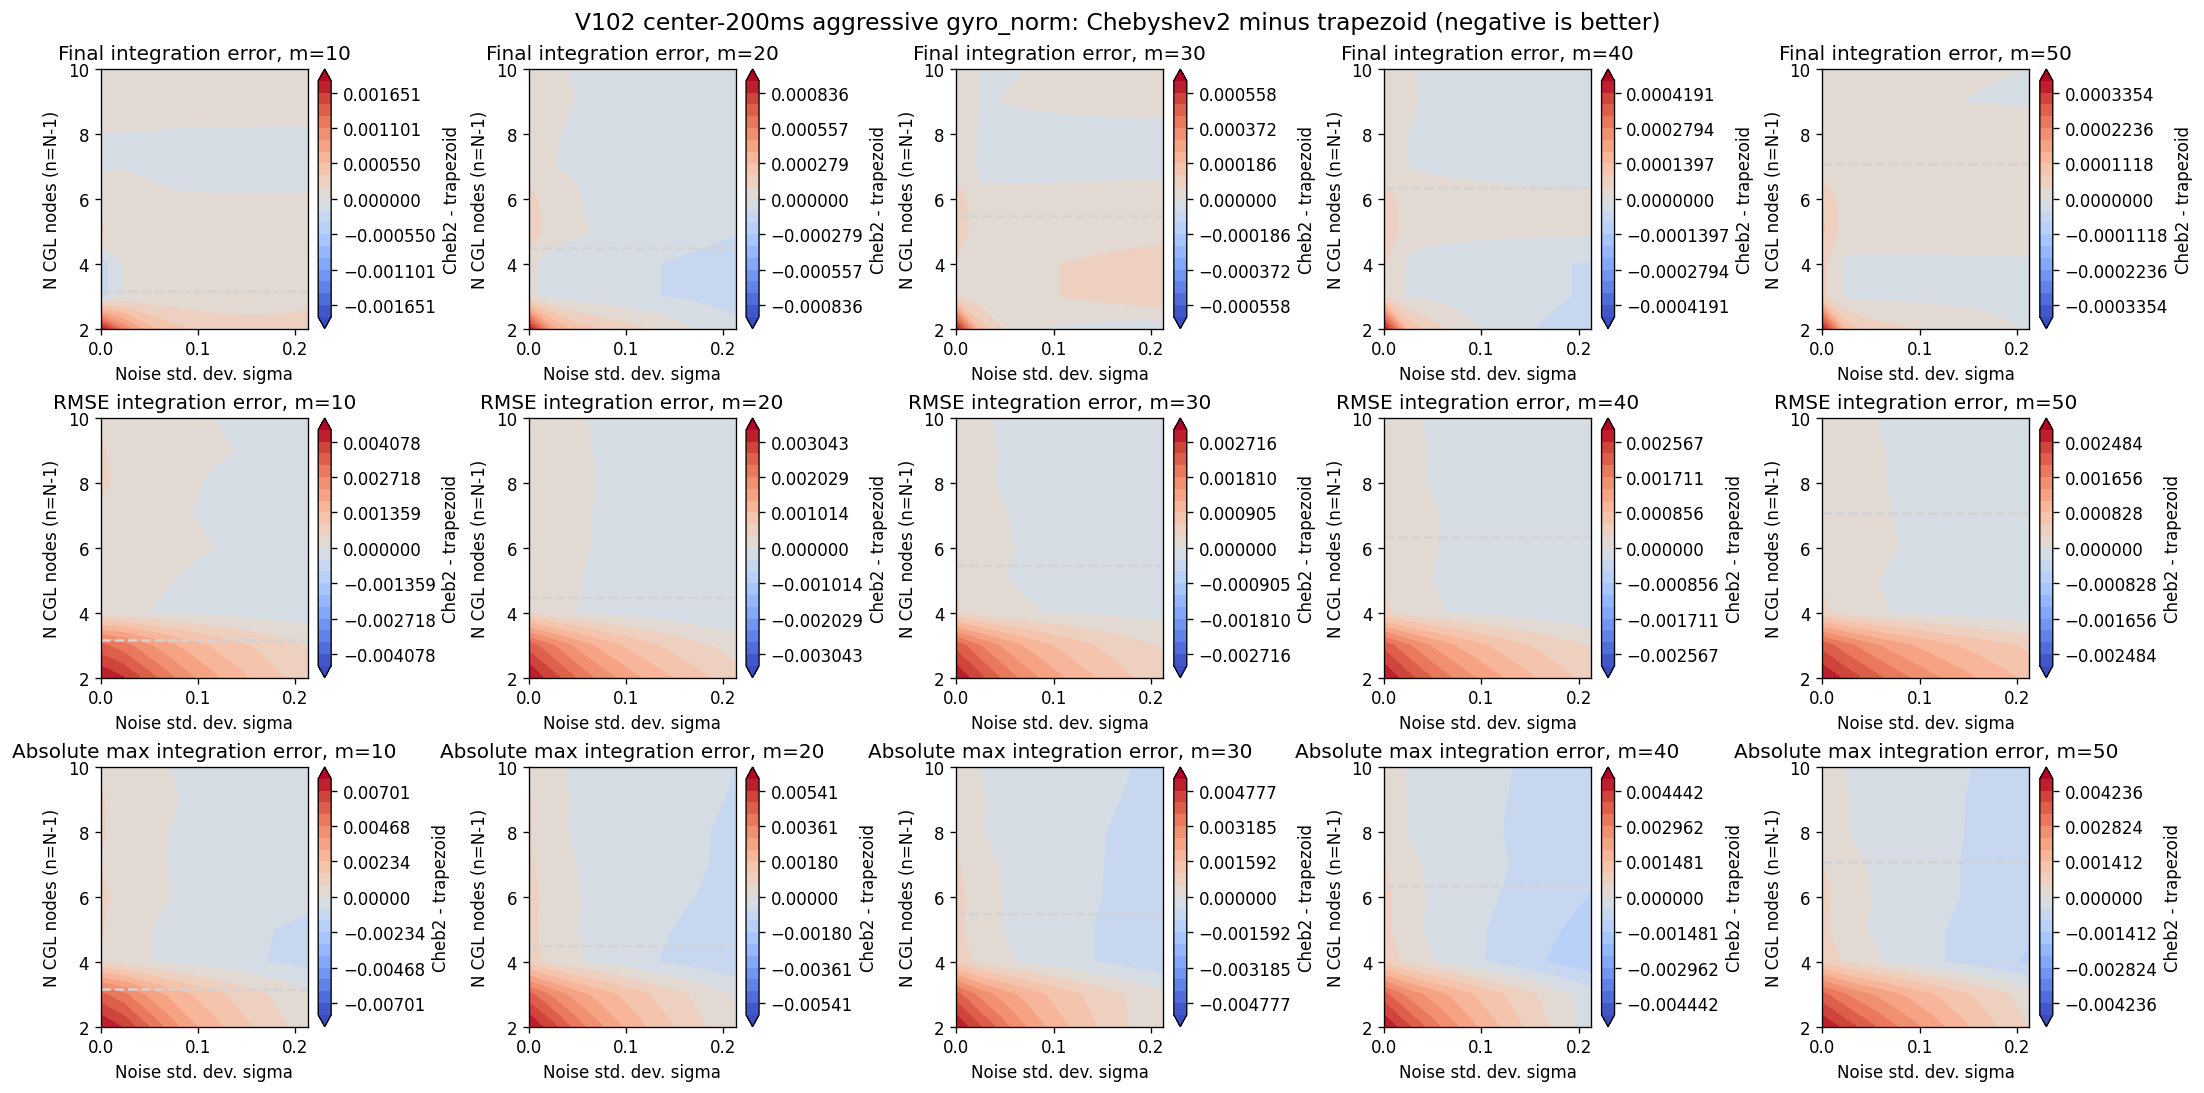

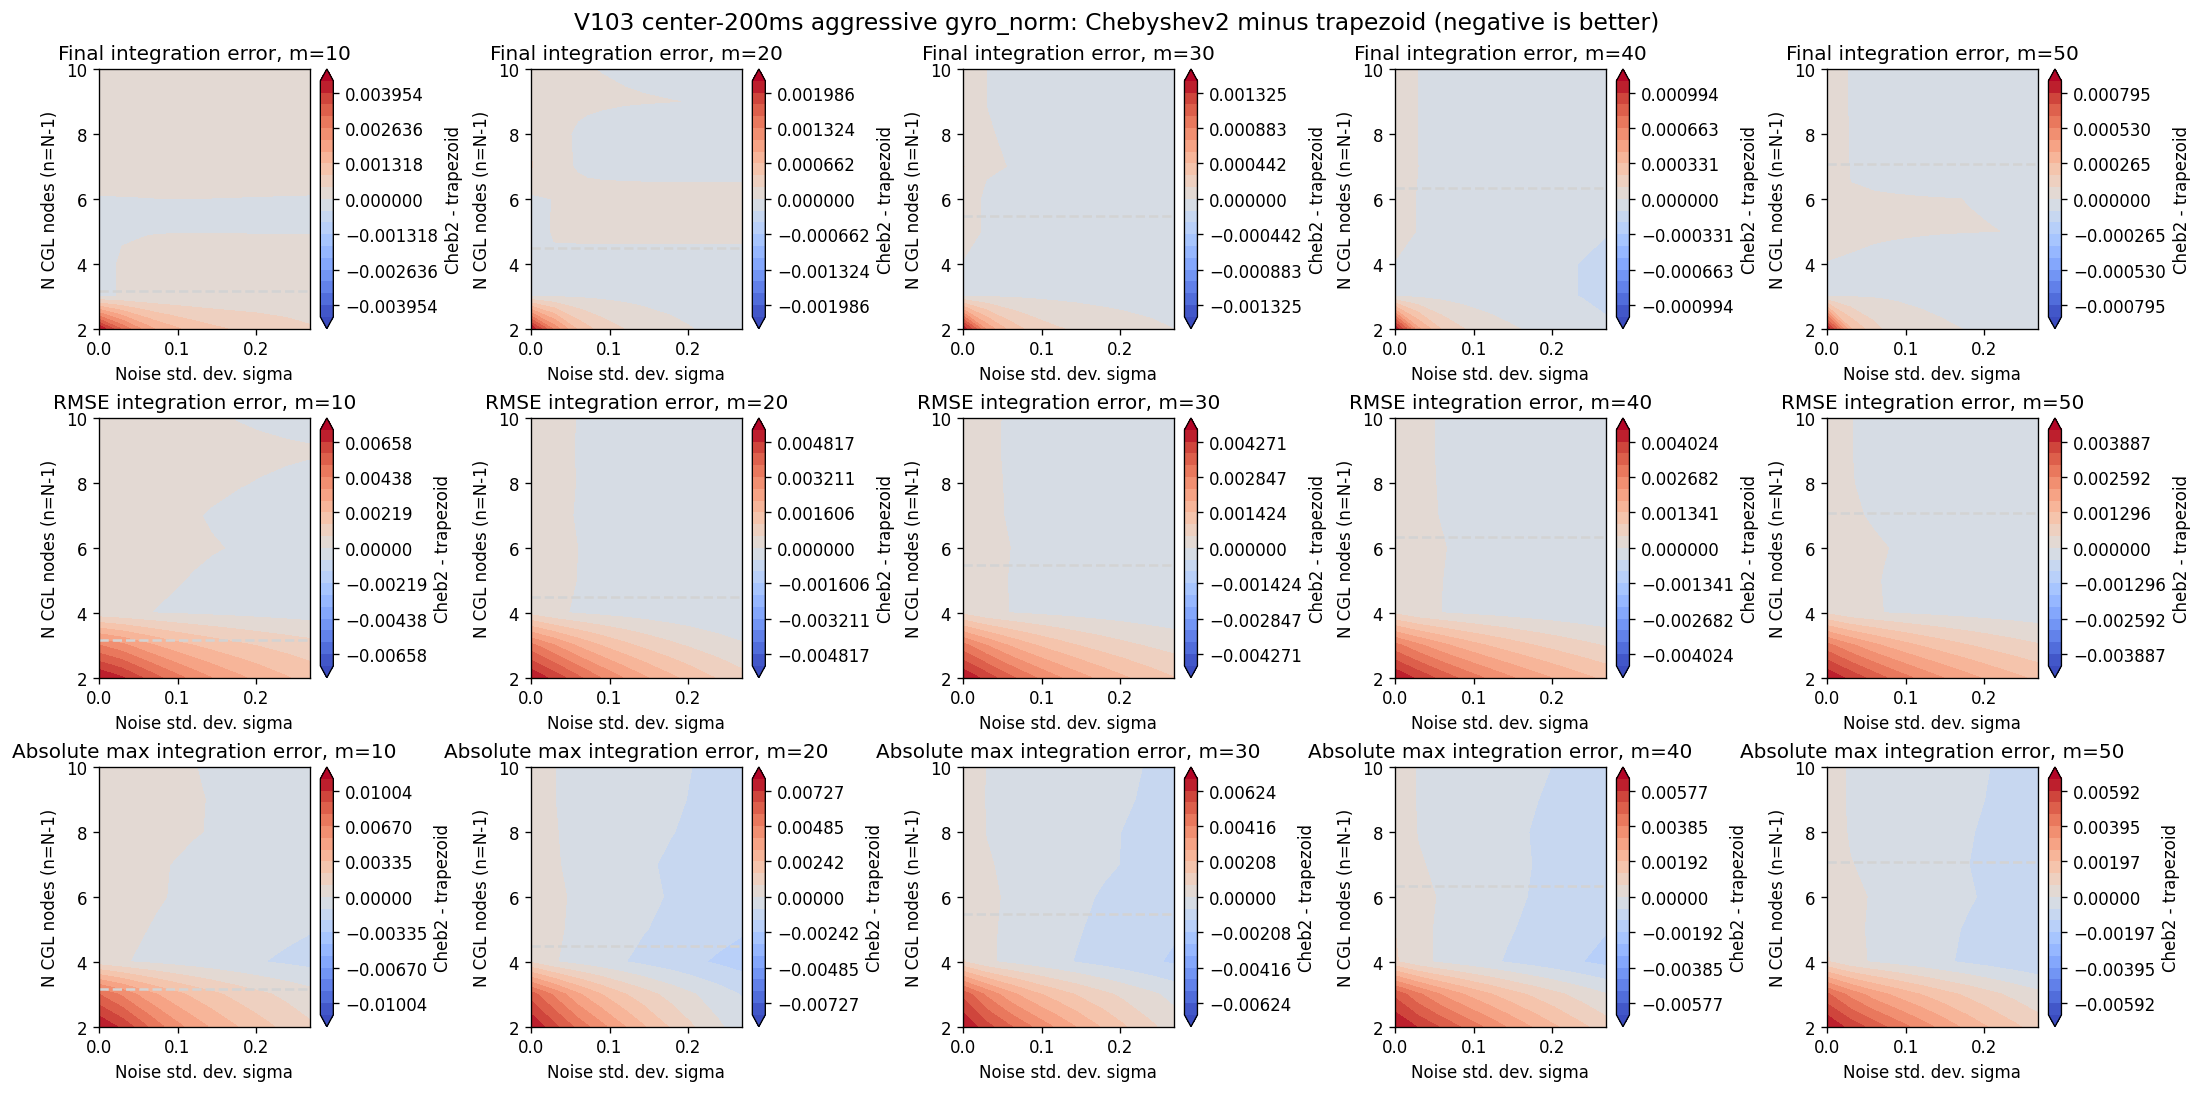

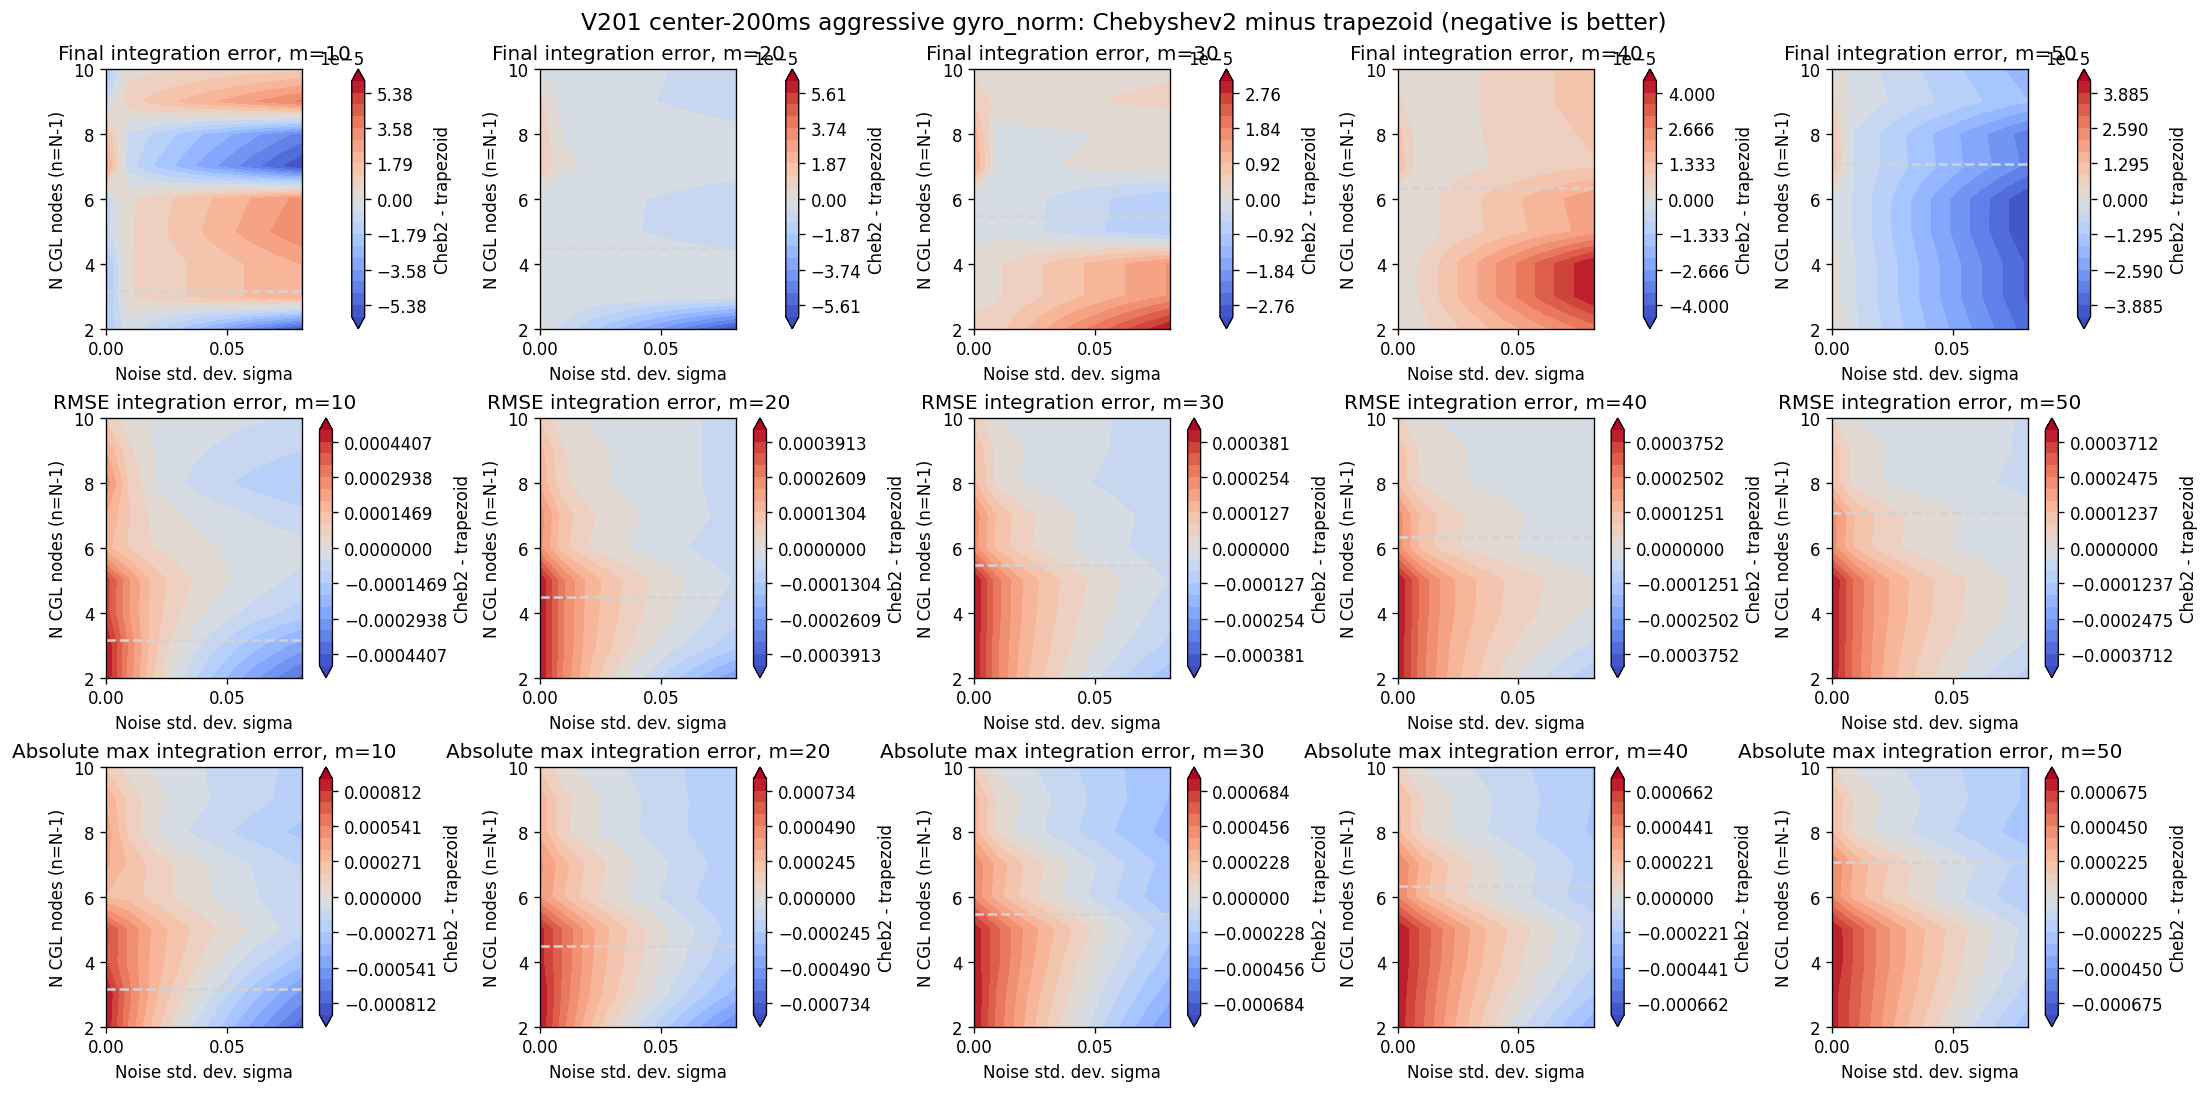

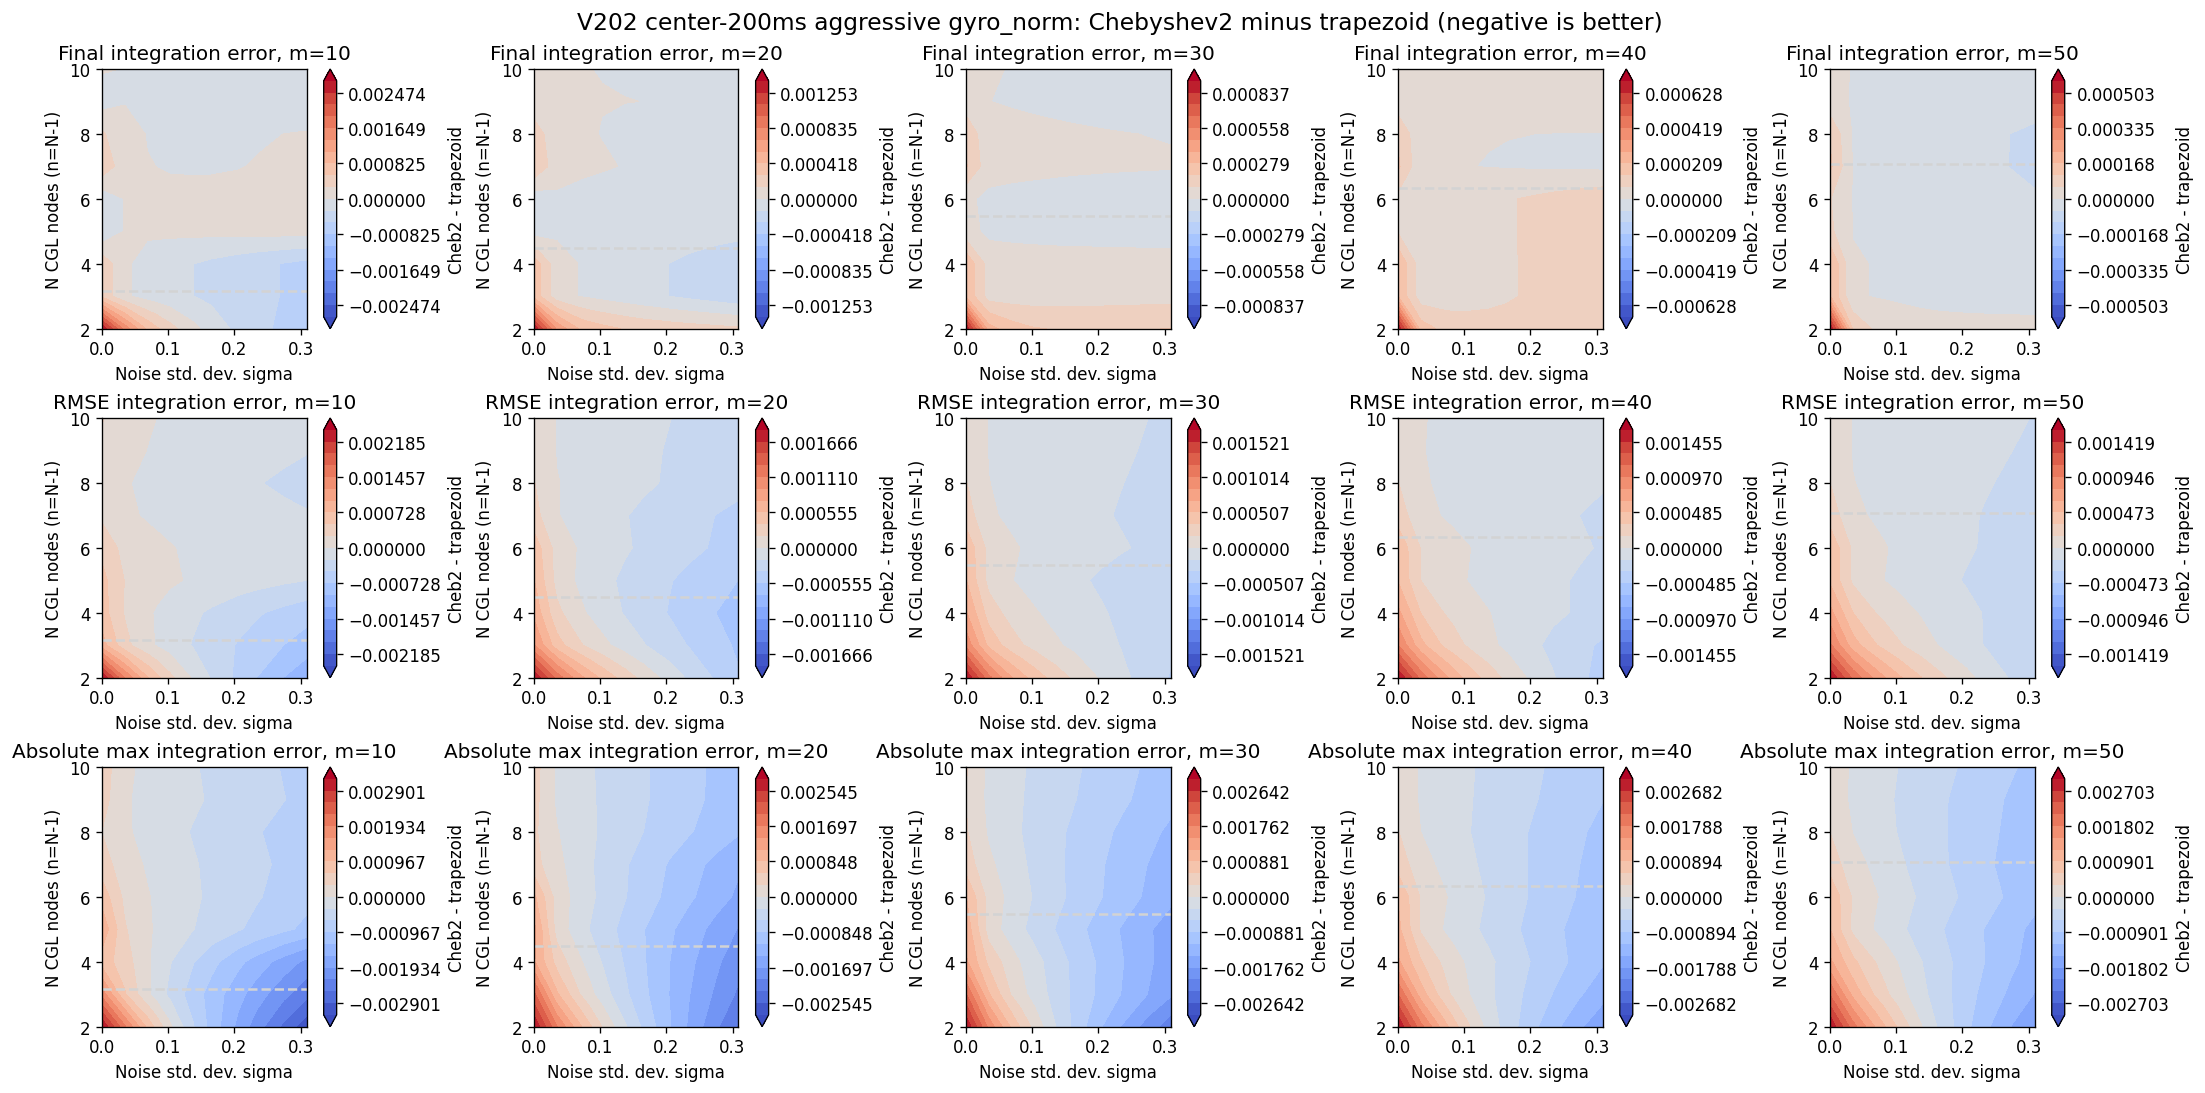

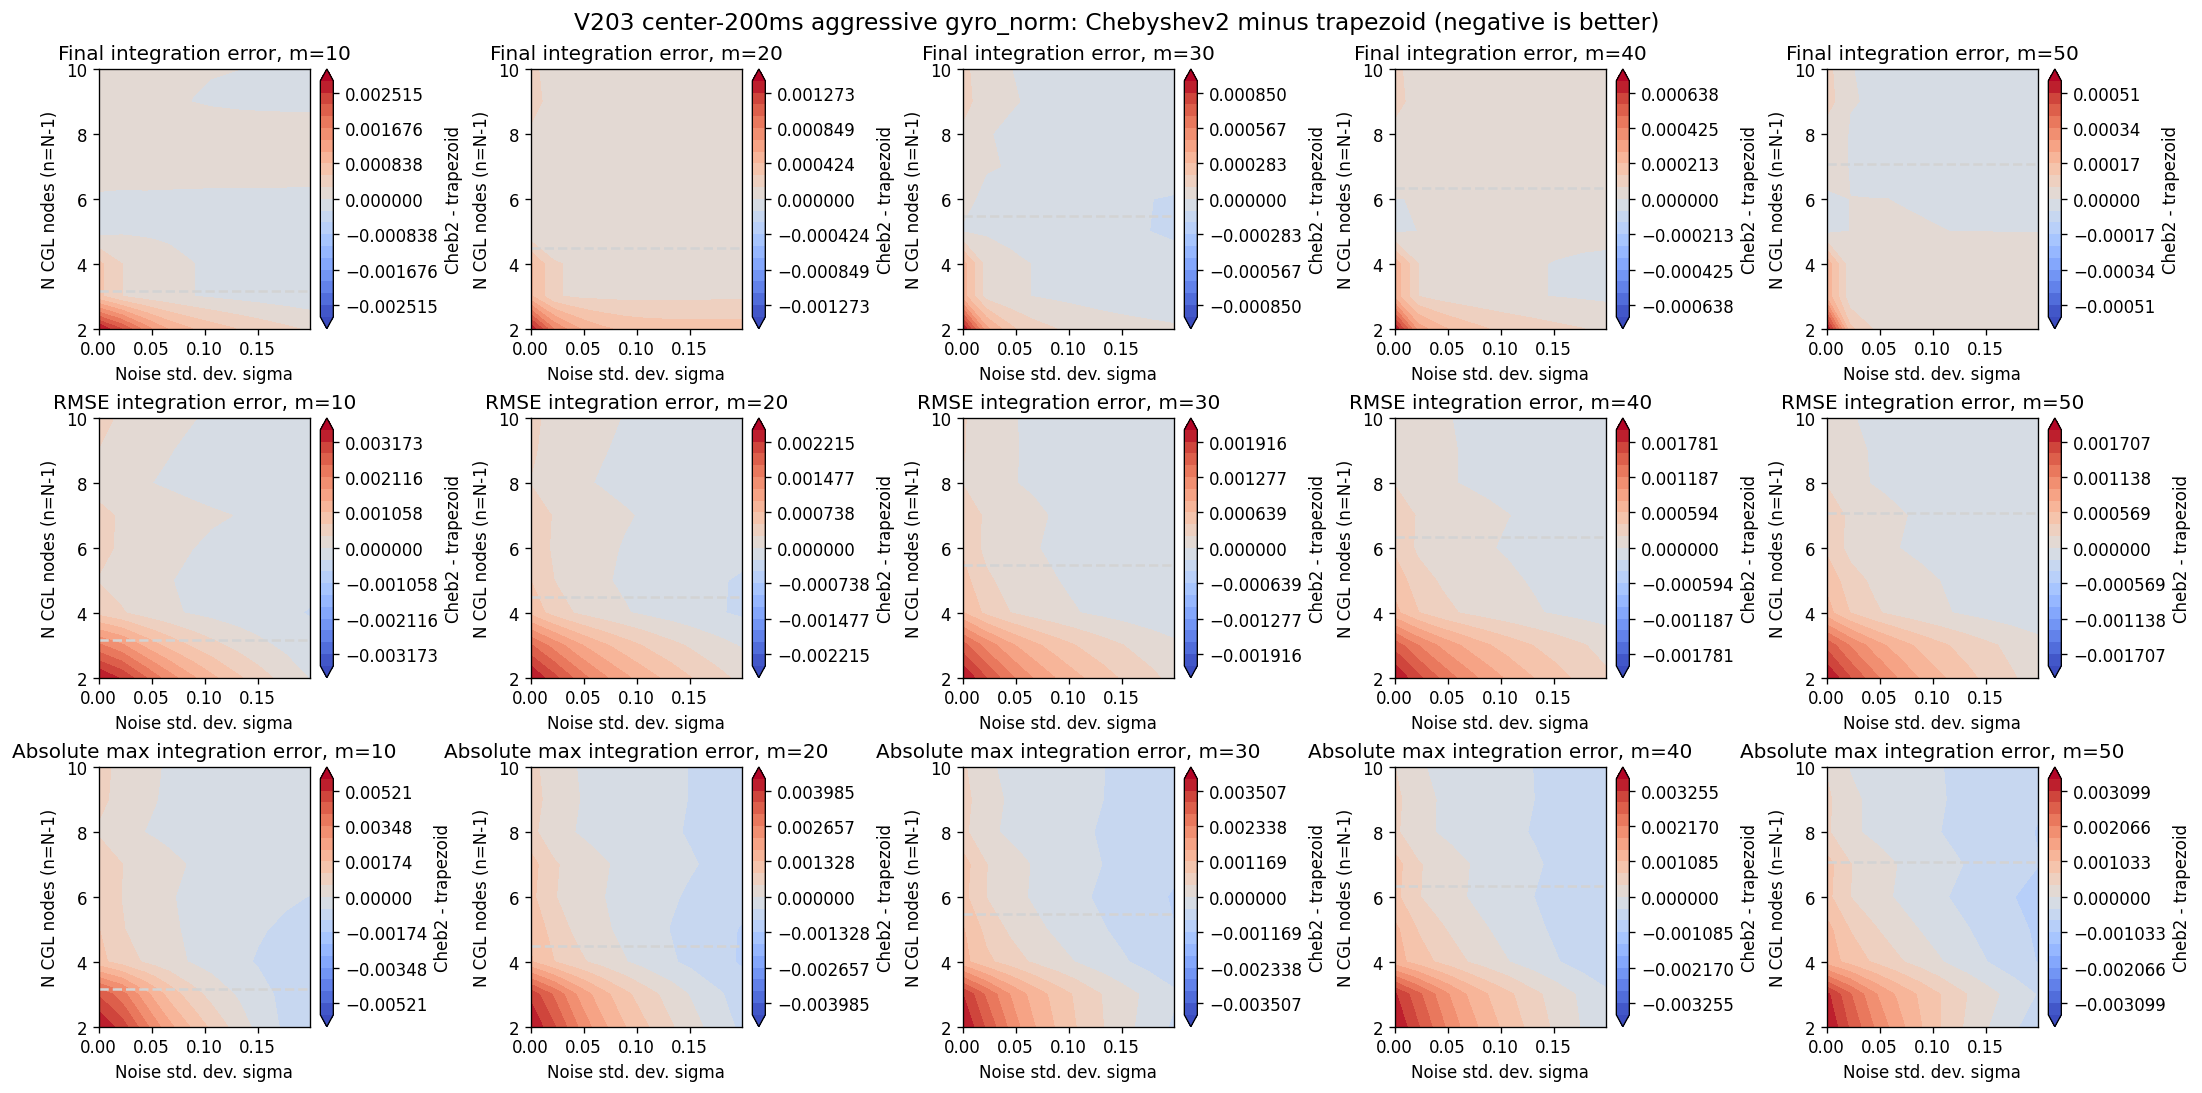

In [23]:
for function in FUNCTIONS:
    fig = scalar_quadrature.plot_fixed_m_comparison(
        comparisons,
        function_name=function.name,
        selected_m_values=M_VALUES,
        show_sqrt_m=True,
    )
    display(fig)
    plt.close(fig)


In [24]:
summary = (
    comparisons.groupby(["function", "m"])[["end_error", "rmse_error", "max_error"]]
    .median()
    .round(6)
)
summary


end_error  rmse_error  max_error
function                               m                                   
MH01 center-200ms aggressive gyro_norm 10   0.000007    0.000050   0.000144
                                       20   0.000001    0.000039   0.000126
                                       30   0.000005    0.000038   0.000096
                                       40   0.000003    0.000057   0.000130
                                       50  -0.000002    0.000057   0.000146
MH02 center-200ms aggressive gyro_norm 10   0.000008    0.000005   0.000042
                                       20  -0.000000    0.000014  -0.000023
                                       30   0.000013    0.000017   0.000001
                                       40  -0.000013    0.000014   0.000010
                                       50  -0.000008    0.000016   0.000027
MH03 center-200ms aggressive gyro_norm 10   0.000021    0.000002  -0.000017
                                       20  -0.000011   -0.000024  -0.000085
                                       30  -0.000014   -0.000003  -0.000083
                                       40  -0.000007    0.000001  -0.000091
                                       50   0.000004   -0.000003  -0.000079
MH04 center-200ms aggressive gyro_norm 10   0.000003    0.000087   0.000170
                                       20  -0.000014    0.000058   0.000112
                                       30  -0.000003    0.000054   0.000061
                                       40  -0.000015    0.000043   0.000054
                                       50  -0.000006    0.000053   0.000053
MH05 center-200ms aggressive gyro_norm 10  -0.000008    0.000031   0.000043
                                       20  -0.000002    0.000016  -0.000005
                                       30  -0.000006    0.000006  -0.000016
                                       40  -0.000006    0.000007  -0.000016
                                       50  -0.000010    0.000006  -0.000011
V101 center-200ms aggressive gyro_norm 10   0.000049    0.000078   0.000114
                                       20  -0.000030    0.000007  -0.000033
                                       30   0.000005   -0.000002  -0.000100
                                       40  -0.000021    0.000010  -0.000051
                                       50   0.000013    0.000011  -0.000054
V102 center-200ms aggressive gyro_norm 10   0.000031    0.000068   0.000007
                                       20  -0.000023   -0.000007  -0.000104
                                       30   0.000009   -0.000018  -0.000147
                                       40  -0.000004   -0.000016  -0.000210
                                       50   0.000004    0.000002  -0.000146
V103 center-200ms aggressive gyro_norm 10   0.000049    0.000118   0.000044
                                       20  -0.000003   -0.000056  -0.000376
                                       30  -0.000023   -0.000041  -0.000240
                                       40  -0.000033   -0.000031  -0.000232
                                       50  -0.000010   -0.000030  -0.000239
V201 center-200ms aggressive gyro_norm 10   0.000008   -0.000008  -0.000004
                                       20  -0.000003    0.000004  -0.000011
                                       30   0.000002   -0.000000  -0.000031
                                       40   0.000007    0.000019   0.000014
                                       50  -0.000013    0.000022   0.000018
V202 center-200ms aggressive gyro_norm 10  -0.000007   -0.000080  -0.000340
                                       20  -0.000018   -0.000129  -0.000505
                                       30   0.000013   -0.000065  -0.000482
                                       40   0.000032   -0.000040  -0.000359
                                       50  -0.000015   -0.000055  -0.000348
V203 center-200ms aggressive gyro_norm 10   0.000034    0.000039  -0.000053
               

## Decision-oriented Plotly views

These views use the same comparison dataframe as the heatmaps above. Positive advantage is `trapezoid error - Chebyshev2 error`, so values above zero favor Chebyshev2. The diamond marks the best median RMSE `N`; the light grey dashed line is `sqrt(m)`. The table reports ideal `N` by metric plus a rank-based robust `N`; exact ties choose the `N` closest to `sqrt(m)`.

In each robust `N` table, `low win`, `med win`, and `high win` are RMSE win rates for the low/middle/high thirds of the configured `noise_fraction` values. A win means `-rmse_error > 0`, i.e. Chebyshev2 has lower RMSE than trapezoid. This measures how often Chebyshev2 wins, not how much it wins by, so read it alongside RMSE advantage.


In [25]:
for function in FUNCTIONS:
    display(
        scalar_quadrature.plot_advantage_curves_by_m(
            comparisons,
            function.name,
            selected_m_values=M_VALUES,
            metric="rmse_error",
            y_range_min_N=5,
        )
    )
    display(
        scalar_quadrature.plot_robust_N_table(
            comparisons,
            function.name,
            selected_m_values=M_VALUES,
        )
    )


In [26]:
def top_N_per_m(summary: pd.DataFrame, top_k: int = 3) -> pd.DataFrame:
    return (
        summary.sort_values(
            ["m", "median_rmse_advantage", "win_rate"],
            ascending=[True, False, False],
        )
        .groupby("m")
        .head(top_k)
        .reset_index(drop=True)
    )


aggregate_summary = (
    scalar_quadrature.win_rate_summary(
        comparisons,
        group_by=("m", "N"),
        metric="rmse_error",
    )
    .rename(
        columns={
            "median_advantage": "median_rmse_advantage",
            "mean_advantage": "mean_rmse_advantage",
        }
    )
)

display(Markdown("### Overall RMSE win rate across snippets and noise levels"))
display(top_N_per_m(aggregate_summary))


### Overall RMSE win rate across snippets and noise levels

,m,N,median_rmse_advantage,mean_rmse_advantage,win_rate,rows
0,10,8,5.330053e-06,-0.000015,0.520661,121
1,10,10,2.381214e-06,-0.000024,0.520661,121
2,10,9,3.724716e-07,-0.000026,0.504132,121
3,20,8,2.646500e-05,0.000022,0.661157,121
4,20,10,2.587575e-05,0.000021,0.710744,121
5,20,9,2.186735e-05,0.000020,0.652893,121
6,30,9,2.929090e-05,0.000024,0.768595,121
7,30,8,2.889269e-05,0.000023,0.743802,121
8,30,10,2.854411e-05,0.000025,0.785124,121
9,40,9,2.136397e-05,0.000018,0.735537,121


## Lambda1 Sweep for m=40, N=floor(sqrt(m))

This sweep reruns only the `m=40` experiment over a broad lambda1 grid at the fixed Chebyshev2 size `N=floor(sqrt(m))`. Win rate here uses the same RMSE-only definition: the fraction of comparisons where Chebyshev2 has lower RMSE than trapezoid. The first table aggregates across all EuRoC snippets and noise levels; the second table breaks the same fixed-`N` sweep out by noise level.


In [27]:
lambda_sweep_runs = []
for lambda1 in LAMBDA1_SWEEP_GRID:
    result = scalar_quadrature.run_scalar_monte_carlo(
        FUNCTIONS,
        m_values=[LAMBDA1_SWEEP_M],
        N_values=[LAMBDA1_SWEEP_N],
        noise_fractions=NOISE_FRACTIONS,
        num_seeds=NUM_SEEDS,
        seed=RANDOM_SEED,
        interval=MIDDLE_INTERVAL,
        evaluation_count=EVALUATION_COUNT,
        lambda1=float(lambda1),
    )
    lambda_sweep_runs.append(result.comparisons)

lambda_sweep_comparisons = pd.concat(lambda_sweep_runs, ignore_index=True).assign(
    lambda1_label=lambda frame: frame["lambda1"].map(lambda value: f"{value:.1e}"),
)

lambda_sweep_summary = (
    scalar_quadrature.win_rate_summary(
        lambda_sweep_comparisons,
        group_by=("lambda1", "N"),
        metric="rmse_error",
    )
    .rename(
        columns={
            "median_advantage": "median_rmse_advantage",
            "mean_advantage": "mean_rmse_advantage",
        }
    )
    .sort_values(
        ["win_rate", "median_rmse_advantage", "mean_rmse_advantage"],
        ascending=[False, False, False],
    )
    .reset_index(drop=True)
)
lambda_sweep_summary["lambda1_label"] = lambda_sweep_summary["lambda1"].map(
    lambda value: f"{value:.1e}"
)
BEST_LAMBDA1_FOR_M40 = float(lambda_sweep_summary.loc[0, "lambda1"])

display(Markdown(f"### Overall lambda1 sweep at N={LAMBDA1_SWEEP_N}"))
display(lambda_sweep_summary.head(10))

lambda_sweep_by_noise = (
    scalar_quadrature.win_rate_summary(
        lambda_sweep_comparisons,
        group_by=("noise_fraction", "lambda1", "N"),
        metric="rmse_error",
    )
    .rename(
        columns={
            "median_advantage": "median_rmse_advantage",
            "mean_advantage": "mean_rmse_advantage",
        }
    )
)
lambda_sweep_by_noise["lambda1_label"] = lambda_sweep_by_noise["lambda1"].map(
    lambda value: f"{value:.1e}"
)

for noise_fraction, table in lambda_sweep_by_noise.groupby("noise_fraction", sort=True):
    display(Markdown(f"### noise_fraction = {noise_fraction:g}"))
    display(
        table.sort_values(
            ["win_rate", "median_rmse_advantage", "mean_rmse_advantage"],
            ascending=[False, False, False],
        )
        .head(5)
        .reset_index(drop=True)
    )


### Overall lambda1 sweep at N=6

,lambda1,N,median_rmse_advantage,mean_rmse_advantage,win_rate,rows,lambda1_label
0,3.162278e-03,6,1.770995e-06,-0.000013,0.512397,121,3.2e-03
1,1.000000e-03,6,3.944245e-07,-0.000013,0.504132,121,1.0e-03
2,3.162278e-04,6,-3.987988e-07,-0.000014,0.495868,121,3.2e-04
3,1.000000e-04,6,-4.829037e-07,-0.000014,0.495868,121,1.0e-04
4,3.162278e-05,6,-5.244379e-07,-0.000014,0.495868,121,3.2e-05
5,1.000000e-05,6,-5.390812e-07,-0.000014,0.495868,121,1.0e-05
6,3.162278e-06,6,-5.438633e-07,-0.000014,0.495868,121,3.2e-06
7,1.000000e-06,6,-5.453906e-07,-0.000014,0.495868,121,1.0e-06
8,3.162278e-07,6,-5.458751e-07,-0.000014,0.495868,121,3.2e-07
9,1.000000e-07,6,-5.460285e-07,-0.000014,0.495868,121,1.0e-07


### noise_fraction = 0

,noise_fraction,lambda1,N,median_rmse_advantage,mean_rmse_advantage,win_rate,rows,lambda1_label
0,0.0,0.003162,6,-0.000224,-0.000247,0.0,11,3.2e-03
1,0.0,0.001000,6,-0.000224,-0.000229,0.0,11,1.0e-03
2,0.0,0.000316,6,-0.000225,-0.000226,0.0,11,3.2e-04
3,0.0,0.000100,6,-0.000225,-0.000226,0.0,11,1.0e-04
4,0.0,0.000032,6,-0.000225,-0.000225,0.0,11,3.2e-05


### noise_fraction = 0.025

...

,noise_fraction,lambda1,N,median_rmse_advantage,mean_rmse_advantage,win_rate,rows,lambda1_label
0,0.17,0.010000,6,0.000052,0.000067,0.909091,11,1.0e-02
1,0.17,0.003162,6,0.000041,0.000057,0.909091,11,3.2e-03
2,0.17,0.001000,6,0.000035,0.000050,0.909091,11,1.0e-03
3,0.17,0.000316,6,0.000033,0.000047,0.909091,11,3.2e-04
4,0.17,0.000100,6,0.000033,0.000046,0.909091,11,1.0e-04


### noise_fraction = 0.2

,noise_fraction,lambda1,N,median_rmse_advantage,mean_rmse_advantage,win_rate,rows,lambda1_label
0,0.2,0.010000,6,0.000066,0.000091,1.000000,11,1.0e-02
1,0.2,0.003162,6,0.000053,0.000074,1.000000,11,3.2e-03
2,0.2,0.031623,6,0.000044,0.000080,1.000000,11,3.2e-02
3,0.2,0.001000,6,0.000048,0.000065,0.909091,11,1.0e-03
4,0.2,0.000316,6,0.000046,0.000062,0.909091,11,3.2e-04


### noise_fraction = 0.225

,noise_fraction,lambda1,N,median_rmse_advantage,mean_rmse_advantage,win_rate,rows,lambda1_label
0,0.225,0.031623,6,0.000080,0.000114,1.0,11,3.2e-02
1,0.225,0.010000,6,0.000077,0.000110,1.0,11,1.0e-02
2,0.225,0.003162,6,0.000065,0.000088,1.0,11,3.2e-03
3,0.225,0.001000,6,0.000059,0.000077,1.0,11,1.0e-03
4,0.225,0.000316,6,0.000056,0.000073,1.0,11,3.2e-04


In [28]:
lambda_by_noise = lambda_sweep_by_noise.copy()
ordered_labels = [f"{value:.1e}" for value in LAMBDA1_SWEEP_GRID]
win_rate_image = (
    lambda_by_noise.pivot(
        index="lambda1_label", columns="noise_fraction", values="win_rate"
    )
    .reindex(ordered_labels)
)

fig = go.Figure(
    data=go.Heatmap(
        z=win_rate_image.to_numpy(dtype=float),
        x=[f"{value:g}" for value in win_rate_image.columns],
        y=win_rate_image.index,
        colorscale="Viridis",
        zmin=0.0,
        zmax=1.0,
        colorbar_title="RMSE win rate",
    )
)
fig.update_layout(
    title=(
        f"m={LAMBDA1_SWEEP_M}, N={LAMBDA1_SWEEP_N}: "
        f"lambda1 sweep RMSE win rate; best lambda1={BEST_LAMBDA1_FOR_M40:.3g}"
    ),
    xaxis_title="noise fraction",
    yaxis_title="lambda1",
    yaxis_autorange="reversed",
    height=520,
    margin=dict(l=90, r=40, t=80, b=60),
)
fig.show()
